Loading waterbirds: 100%|██████████| 11788/11788 [02:01<00:00, 97.06it/s] 


Number of samples - Train: 4795, Val: 1199, Test: 5794
Confounded ratios - Train: 0.95, Val: 0.50, Test: 0.50


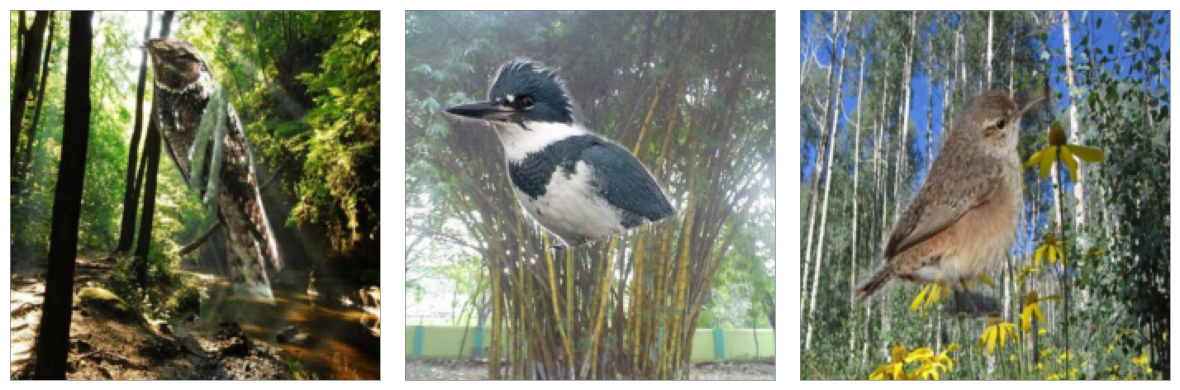

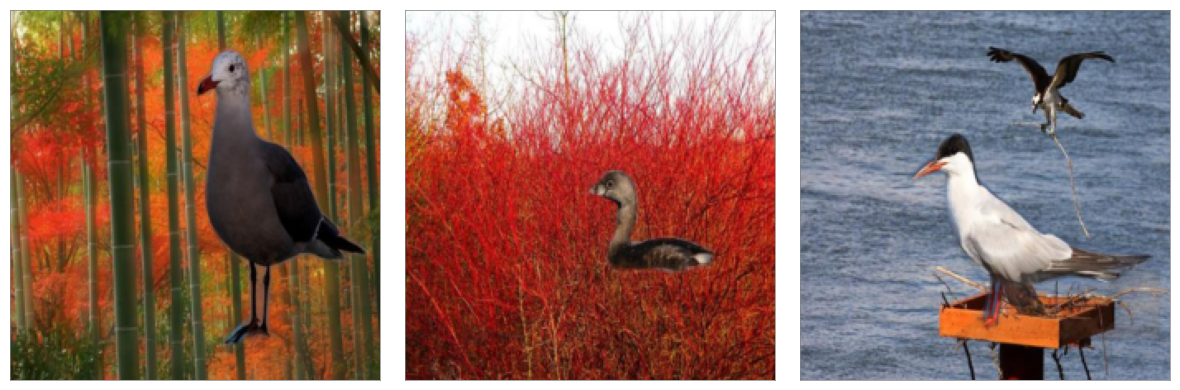

In [1]:
from dataset.dataset import load_data, visualize_k_samples
import matplotlib.pyplot as plt
train_set, val_set, test_set = load_data(
  "Waterbirds", reload=True
)
visualize_k_samples(dataset=train_set, label=0, k=3)
visualize_k_samples(dataset=test_set, label=1, k=3)

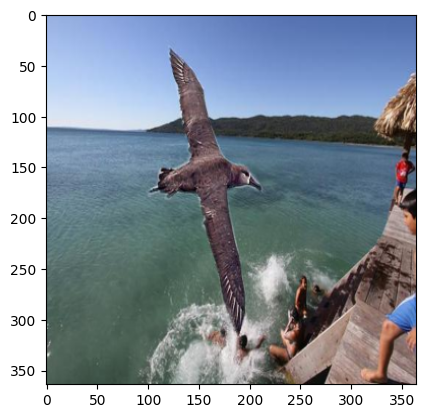

In [3]:
from dataset.dataset import load_data, visualize_k_samples

train_set, val_set, test_set = load_data(
    "DecoyFashionMNIST", 
    seed=123, 
    reload=True,
    bias_ratio=[0.99]*10,
    variation=2
  )



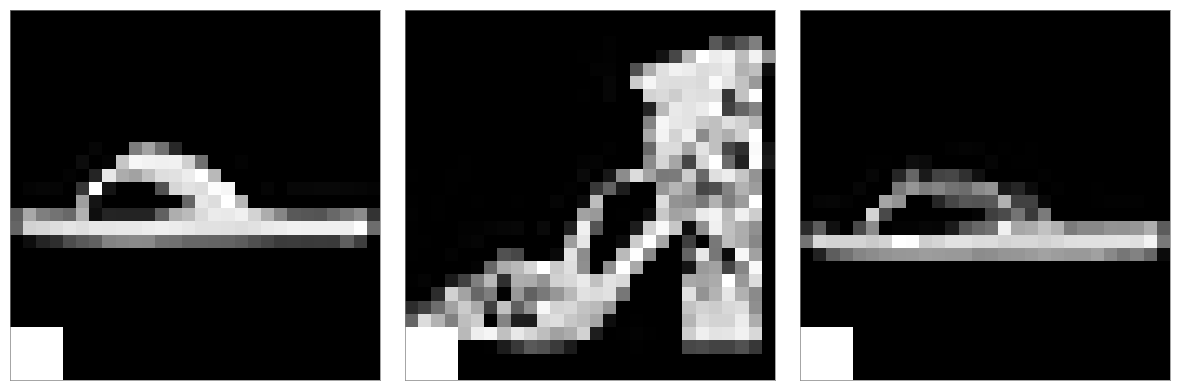

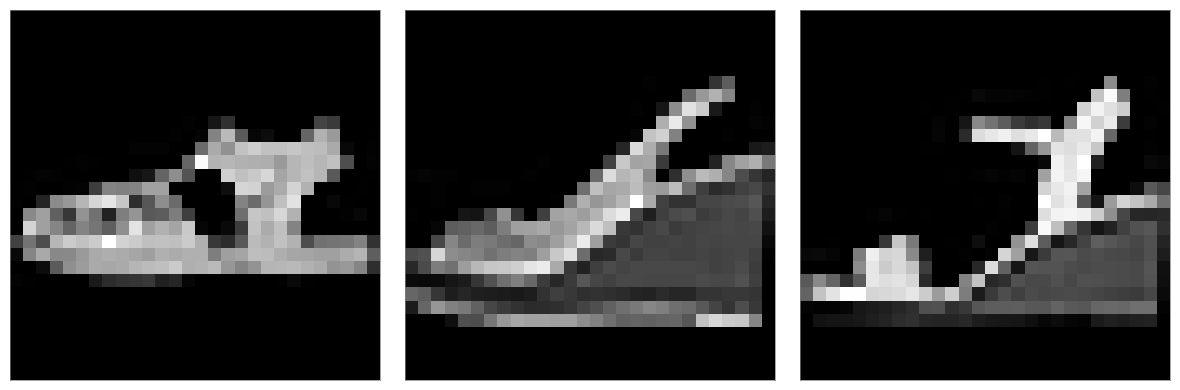

In [4]:
visualize_k_samples(dataset=train_set, label=5, k=3)
visualize_k_samples(dataset=test_set, label=5, k=3)

In [ ]:
# Visualize if model is confounded
import torch
import numpy as np
from model.model import load_model
from dataset.dataset import load_data, create_dataloaders
from functions.optimizer import load_optimizer
from functions.loss import load_loss_fun
from functions.functions import train_model, eval_model, save_checkpoint, load_checkpoint
from functions.xai import explain_dataset, visualize_k_expl, evaluate_explainations
from utils.utils import enable_reproducibility

def see_explainations(model_name, dataset, bias_ratio,conf_type, seed=123):
  use_cuda = torch.cuda.is_available()
  device = 'cuda' if use_cuda else 'cpu'
  enable_reproducibility(seed)

  model = load_model(model_name, device=device)
  optim = load_optimizer("SGD", model.parameters(), lr=1e-2, weight_decay=0)
  loss = load_loss_fun("CrossEntropy")

  train_set, val_set, test_set = load_data(
    dataset, 
    seed=seed, 
    reload=True,
    bias_ratio=bias_ratio,
    variation=conf_type
  )
  
  data = [train_set, val_set, test_set]
  params = {"batch_size":32}
  m_params = [params]*3
  train_loader, val_loader, test_loader = create_dataloaders(data, m_params)

  _, _ = train_model(
    model=model, 
    train_loader=train_loader, 
    optimizer=optim, 
    loss_fun=loss, 
    n_epochs=10, 
    eval_loader=val_loader, 
    device=device
  )
  attrs, imgs = explain_dataset(train_loader, model, device)
  print(evaluate_explainations(attrs, train_set.masks, train_set.y)) 
  for cls in range(10):
    visualize_k_expl(attrs, imgs, train_set, cls, 3)

Epoch 10/10: 100%|██████████| 10/10 [05:23<00:00, 32.34s/it, loss=0.0185, acc=0.9950, val_loss=1.3629, val_acc=0.6086]


(0.5592185258865356, {0: 0.8809582591056824, 1: 0.40895259380340576, 2: 0.7425360679626465, 3: 0.5776658654212952, 4: 0.851174533367157, 5: 0.615402340888977, 6: 0.8007595539093018, 7: 0.7342961430549622, 8: 0.7406368255615234, 9: 0.7701375484466553})


Epoch 10/10: 100%|██████████| 10/10 [06:17<00:00, 37.71s/it, loss=0.0493, acc=0.9845, val_loss=0.0622, val_acc=0.9824]


(0.6166683435440063, {0: 0.8787282109260559, 1: 0.3358214199542999, 2: 0.6353712677955627, 3: 0.5889158248901367, 4: 0.7121679782867432, 5: 0.5398361086845398, 6: 0.7039749622344971, 7: 0.5869141817092896, 8: 0.8120402097702026, 9: 0.6503981351852417})


Epoch 10/10: 100%|██████████| 10/10 [05:54<00:00, 35.48s/it, loss=0.0270, acc=0.9916, val_loss=0.5655, val_acc=0.8371]


...

(0.6133836507797241, {0: 0.8897219896316528, 1: 0.354511559009552, 2: 0.6235004663467407, 3: 0.5729644894599915, 4: 0.6983959078788757, 5: 0.5565537810325623, 6: 0.6819502711296082, 7: 0.5484187006950378, 8: 0.8149986267089844, 9: 0.6271603107452393})


Epoch 10/10: 100%|██████████| 10/10 [06:55<00:00, 41.52s/it, loss=0.0420, acc=0.9865, val_loss=0.1987, val_acc=0.9394]


(0.5506088733673096, {0: 0.9193940162658691, 1: 0.29666849970817566, 2: 0.6221498250961304, 3: 0.5508080720901489, 4: 0.7408246994018555, 5: 0.54378741979599, 6: 0.692396342754364, 7: 0.5726828575134277, 8: 0.7865704298019409, 9: 0.6751567721366882})


Epoch 10/10: 100%|██████████| 10/10 [04:55<00:00, 29.53s/it, loss=0.0554, acc=0.9828, val_loss=0.0520, val_acc=0.9856]


(0.5900723934173584, {0: 0.8785005211830139, 1: 0.2784275710582733, 2: 0.5922484993934631, 3: 0.5542684197425842, 4: 0.701920747756958, 5: 0.5285565853118896, 6: 0.6865456104278564, 7: 0.5670396685600281, 8: 0.8021013140678406, 9: 0.6130218505859375})


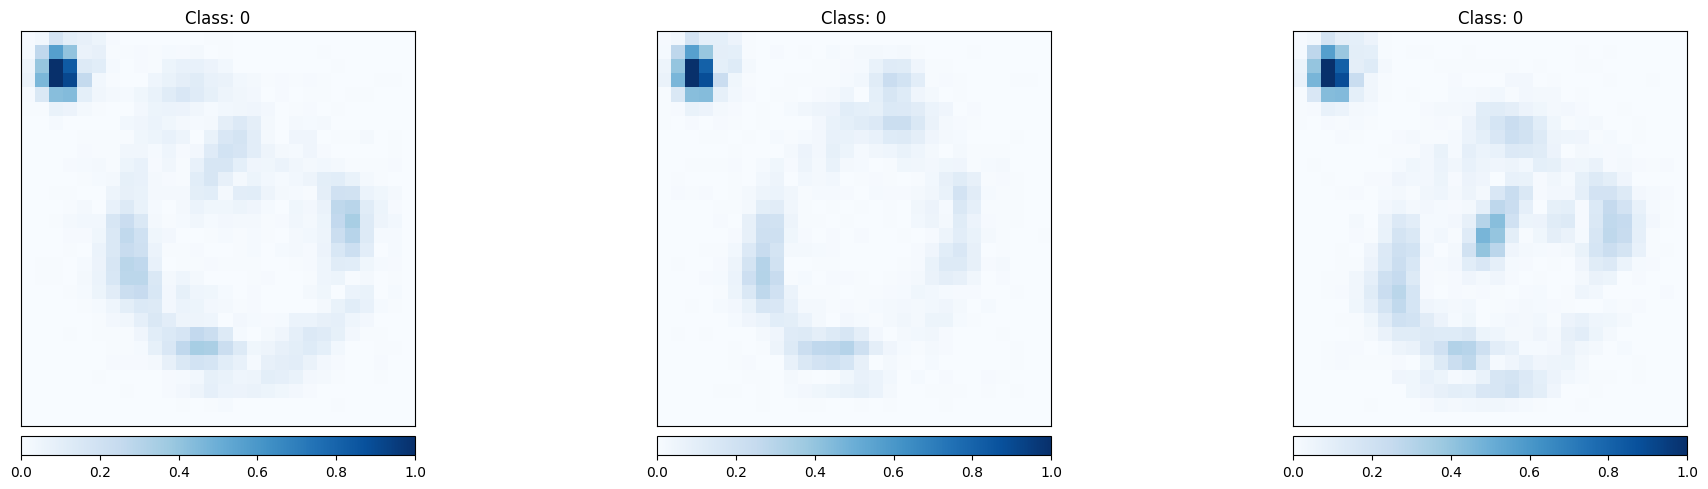

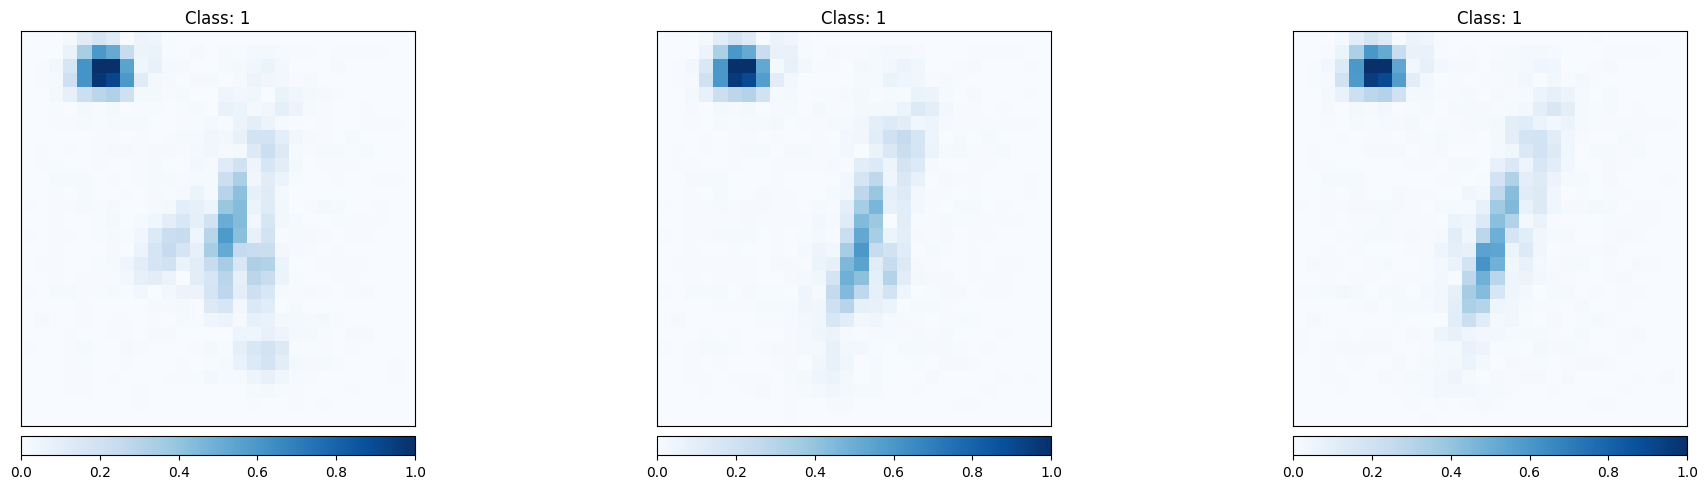

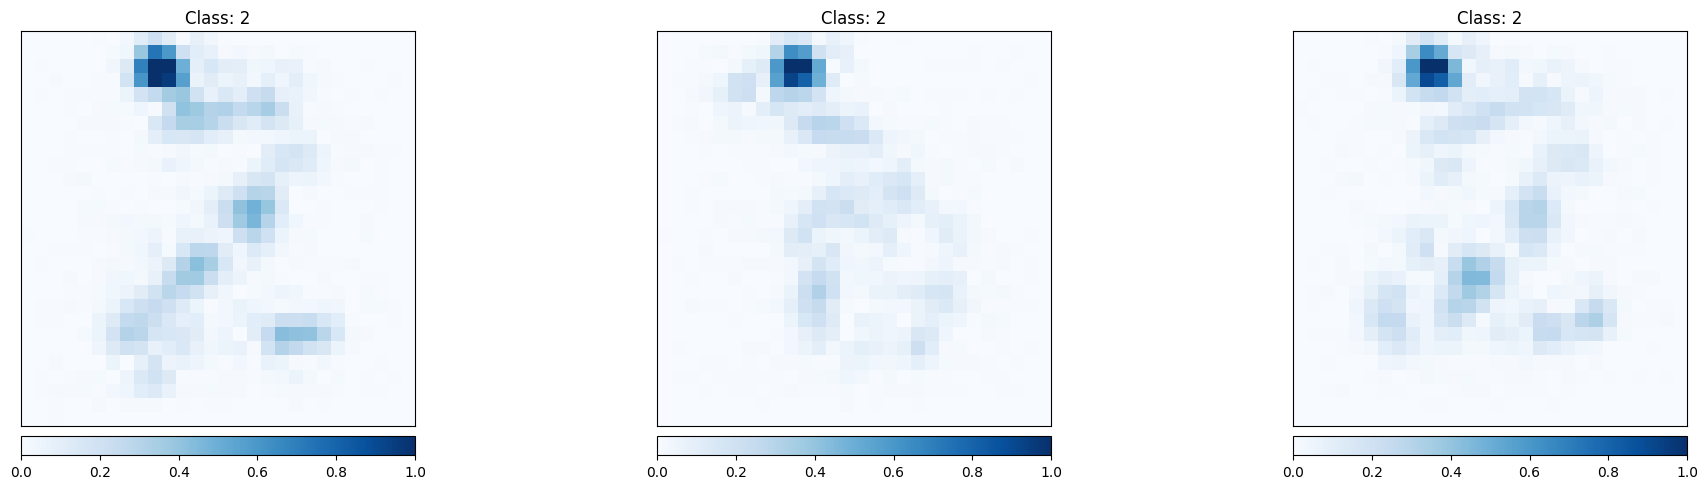

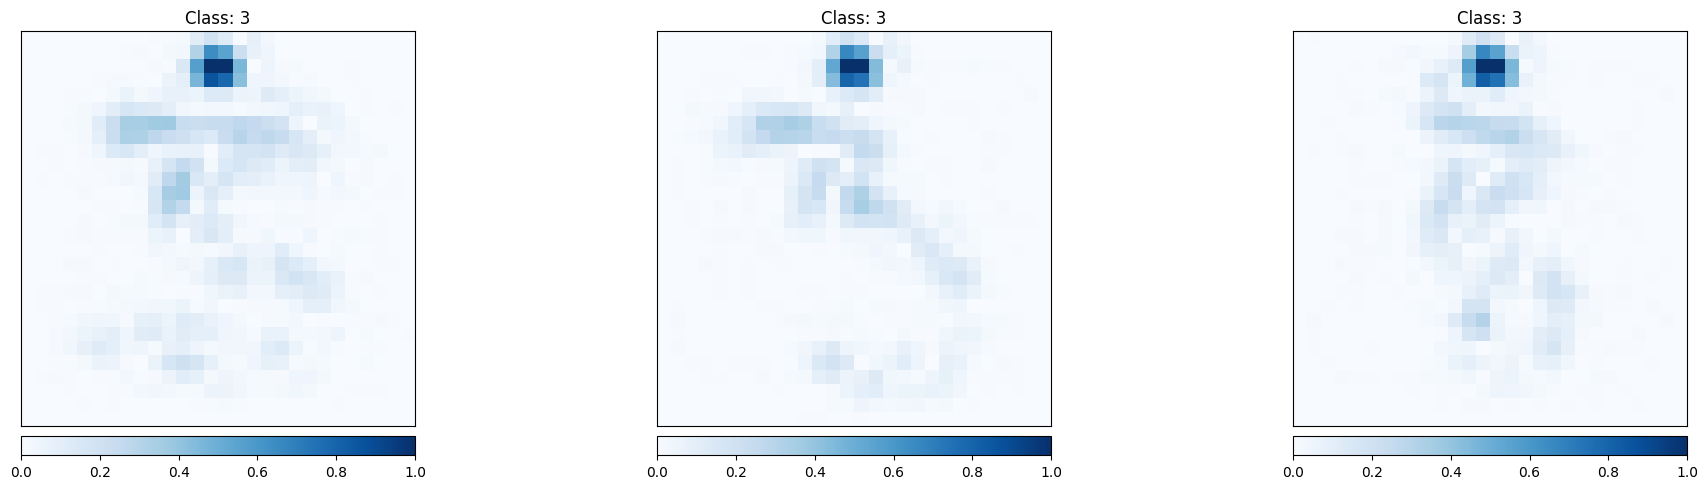

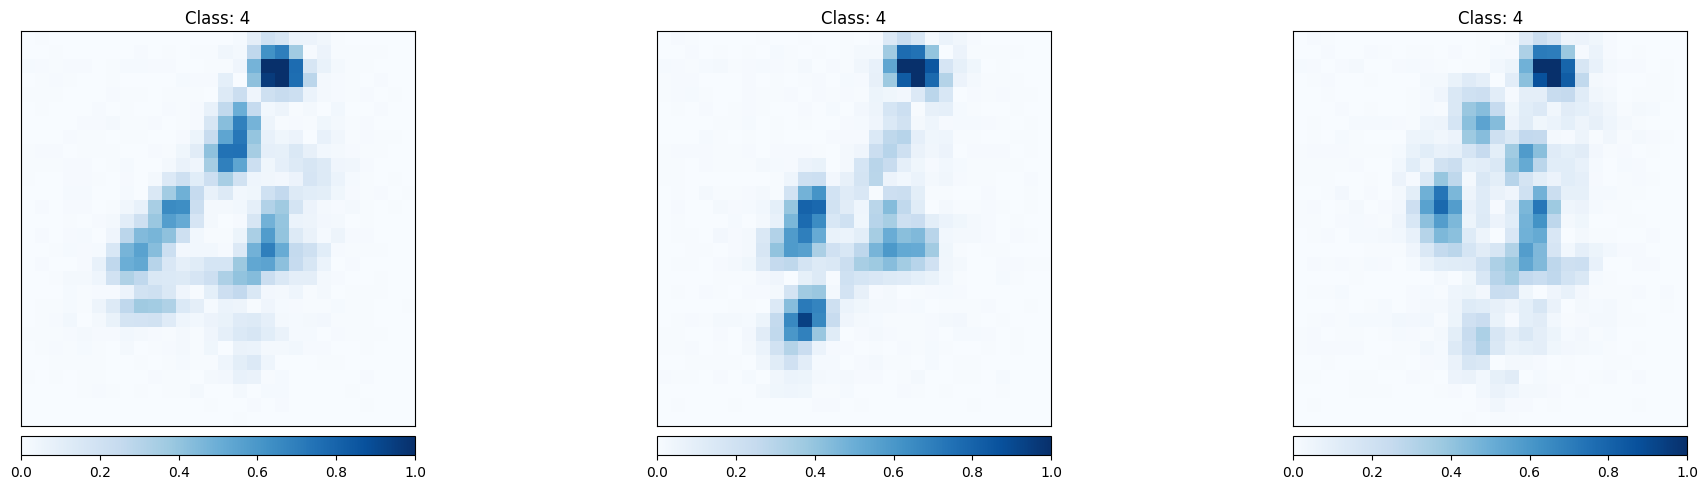

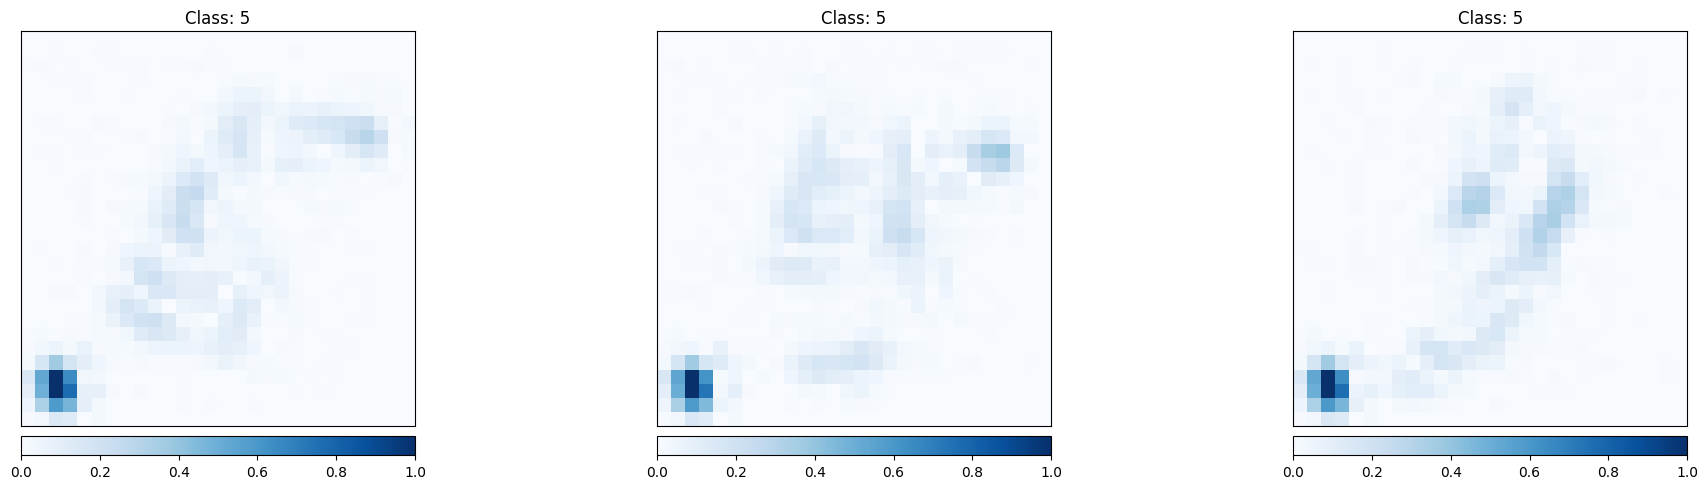

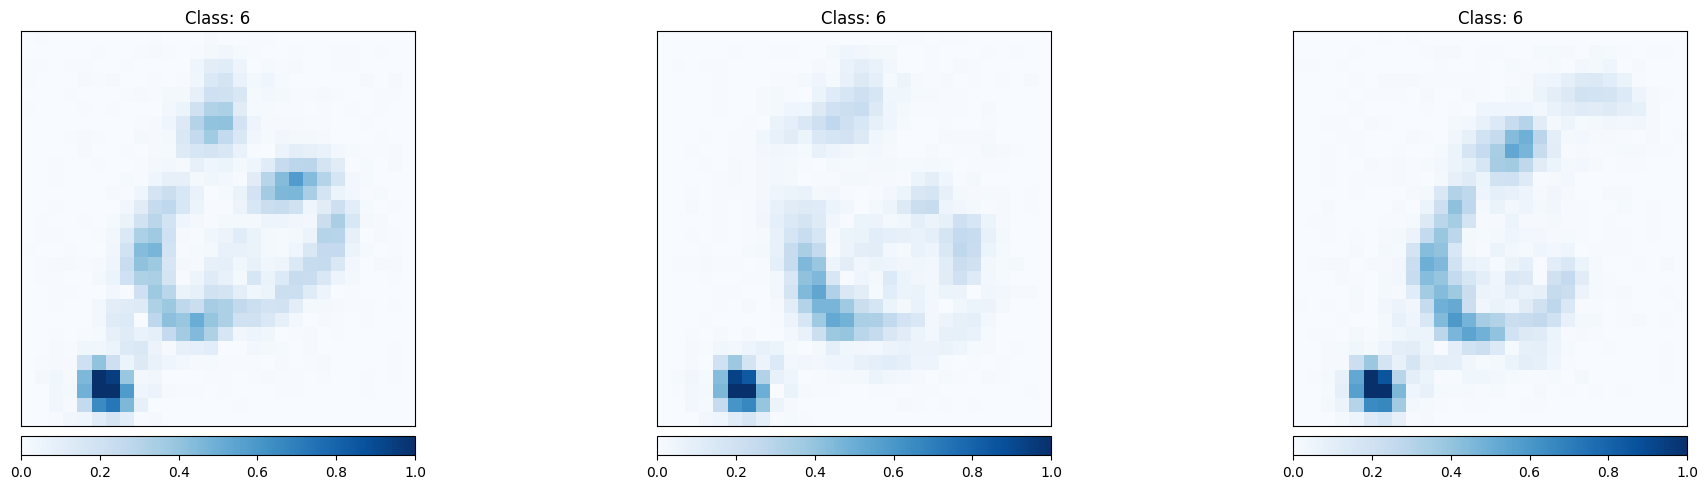

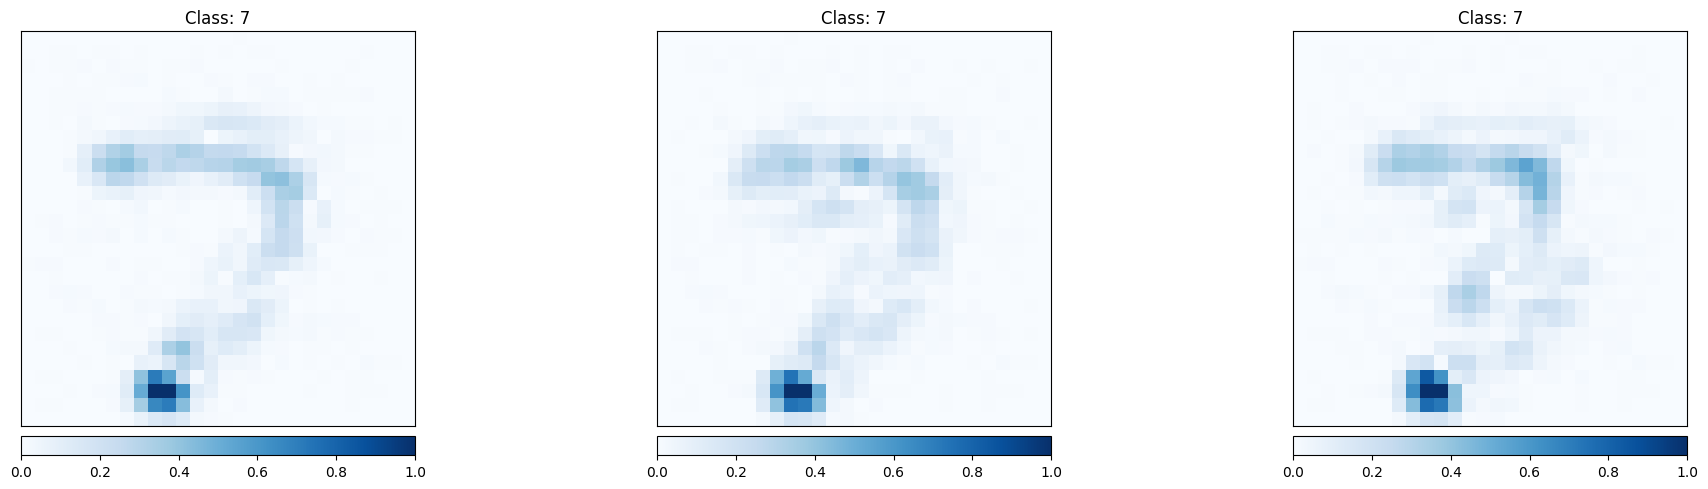

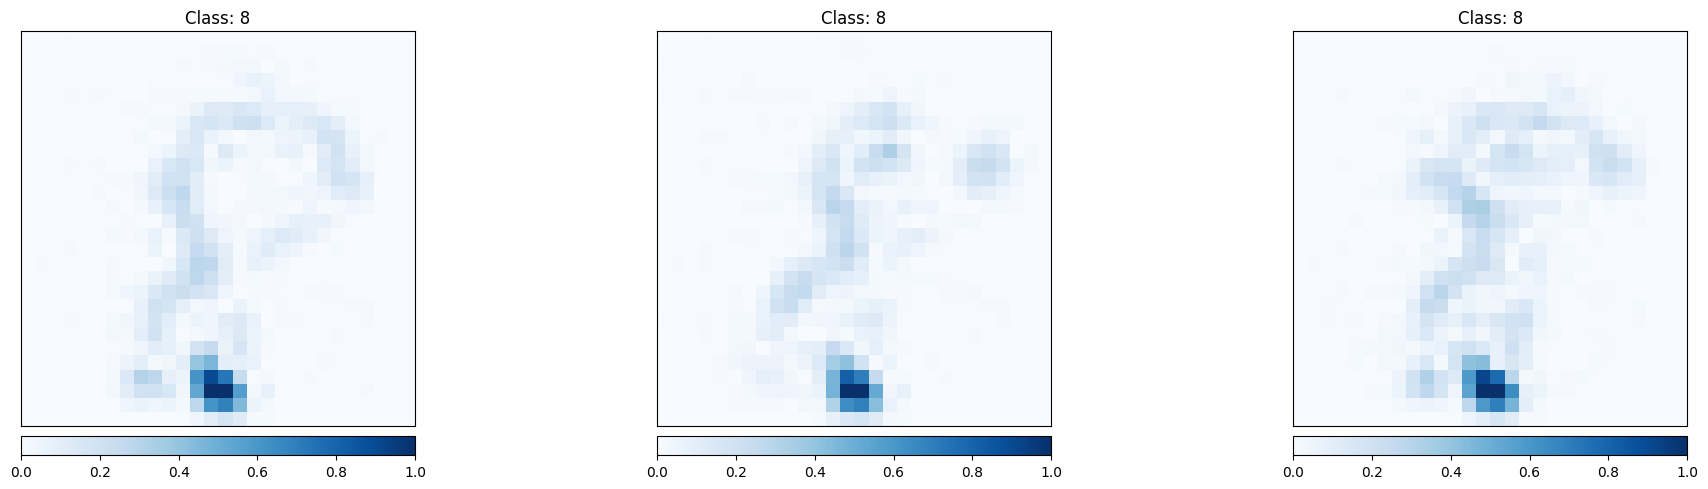

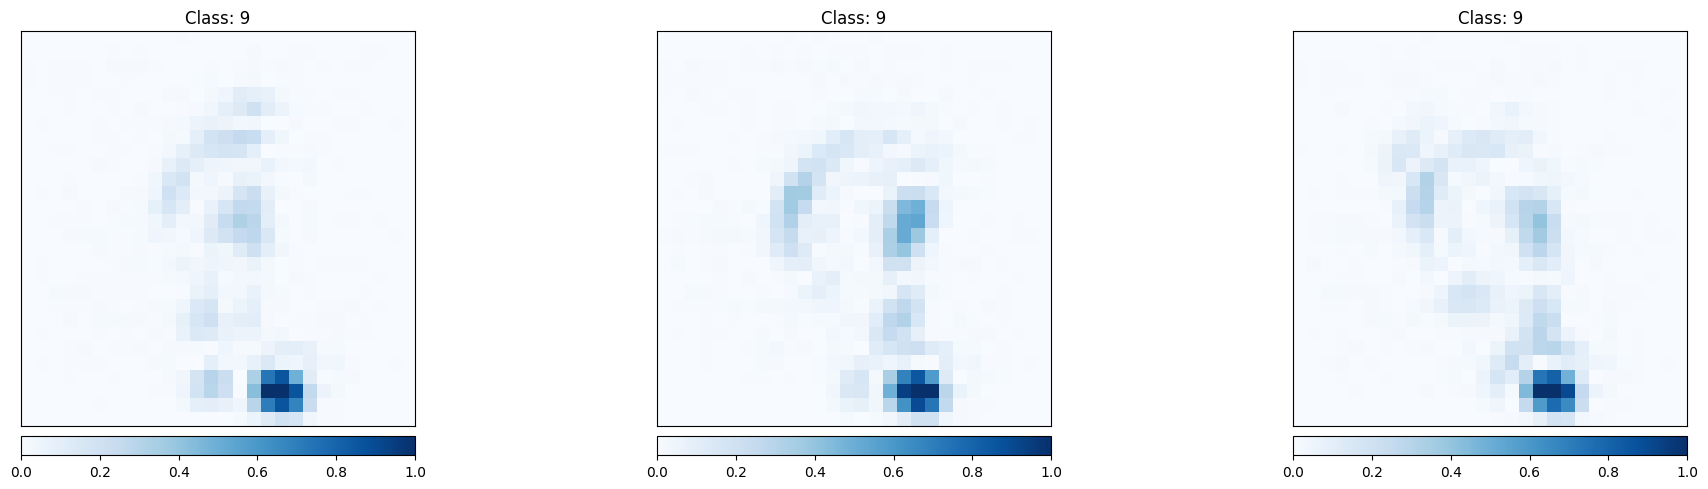

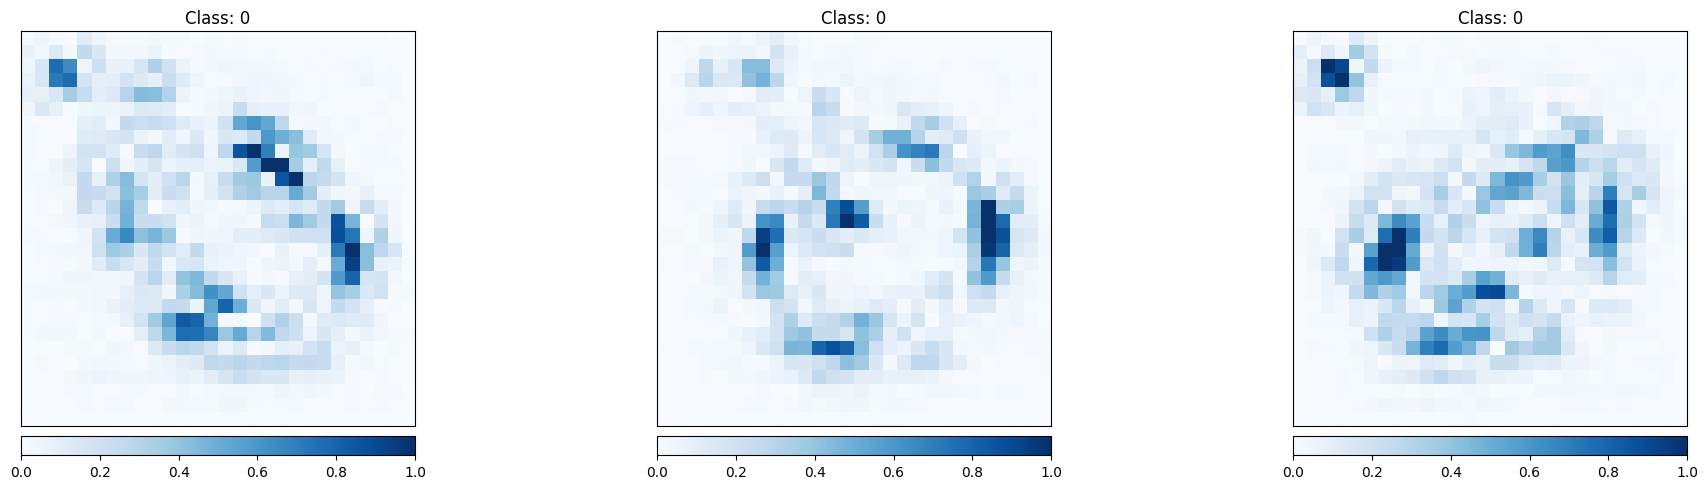

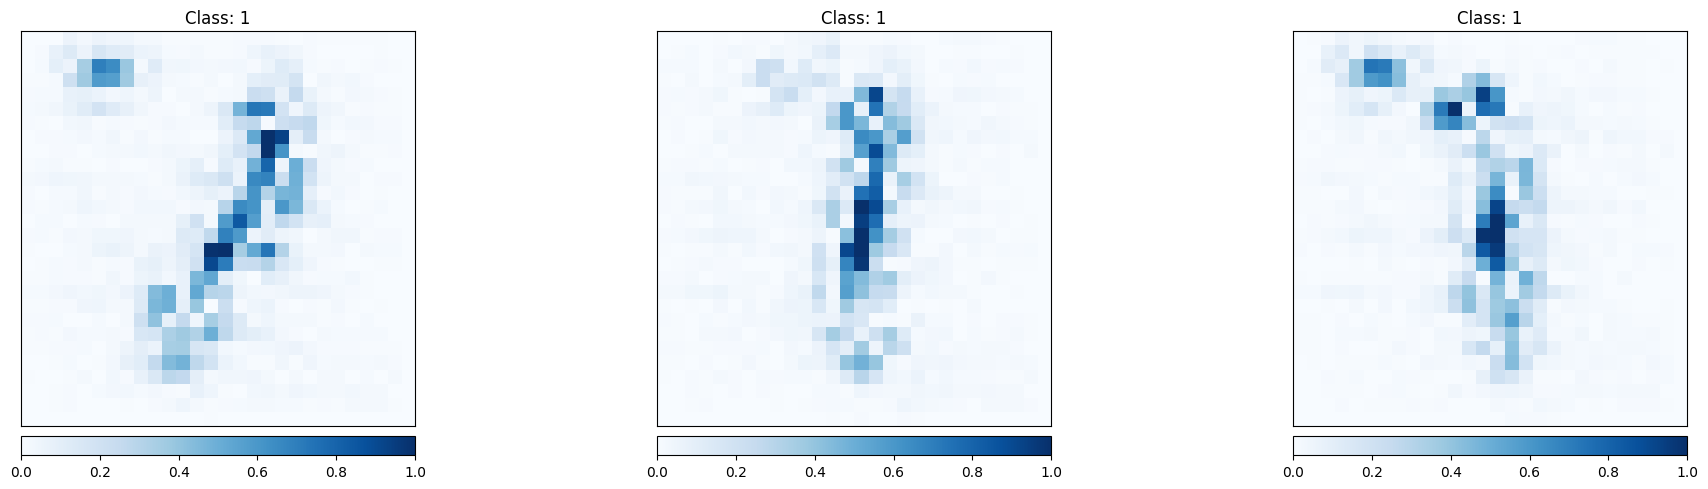

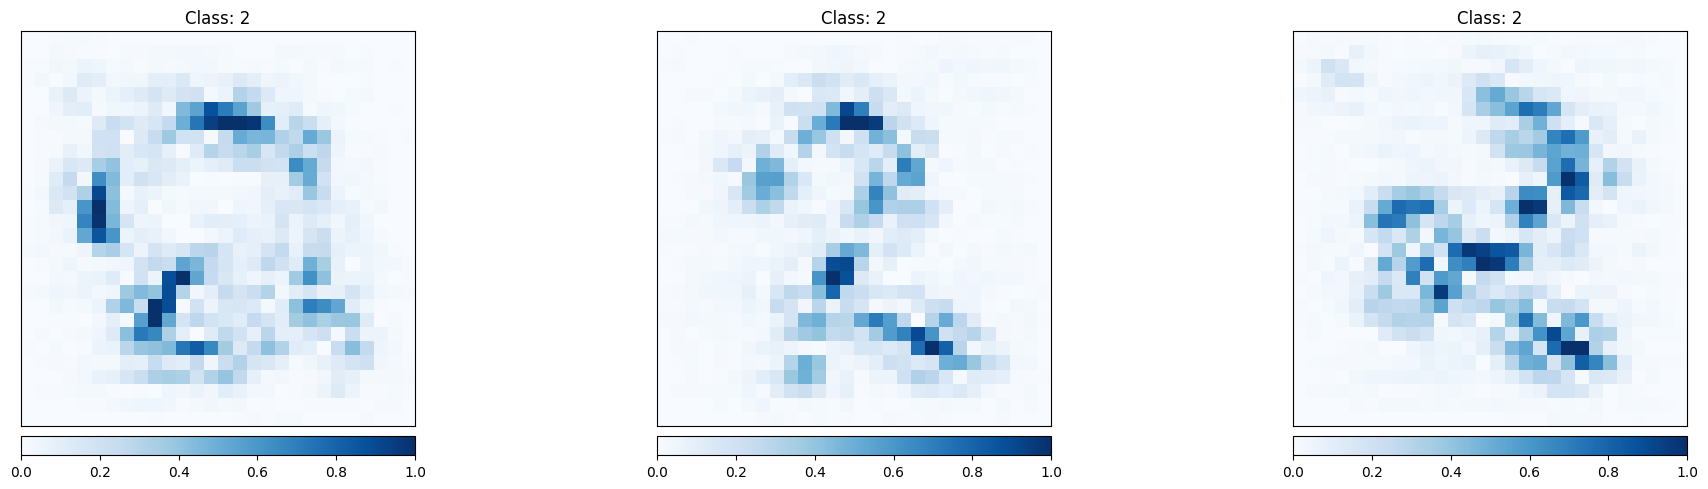

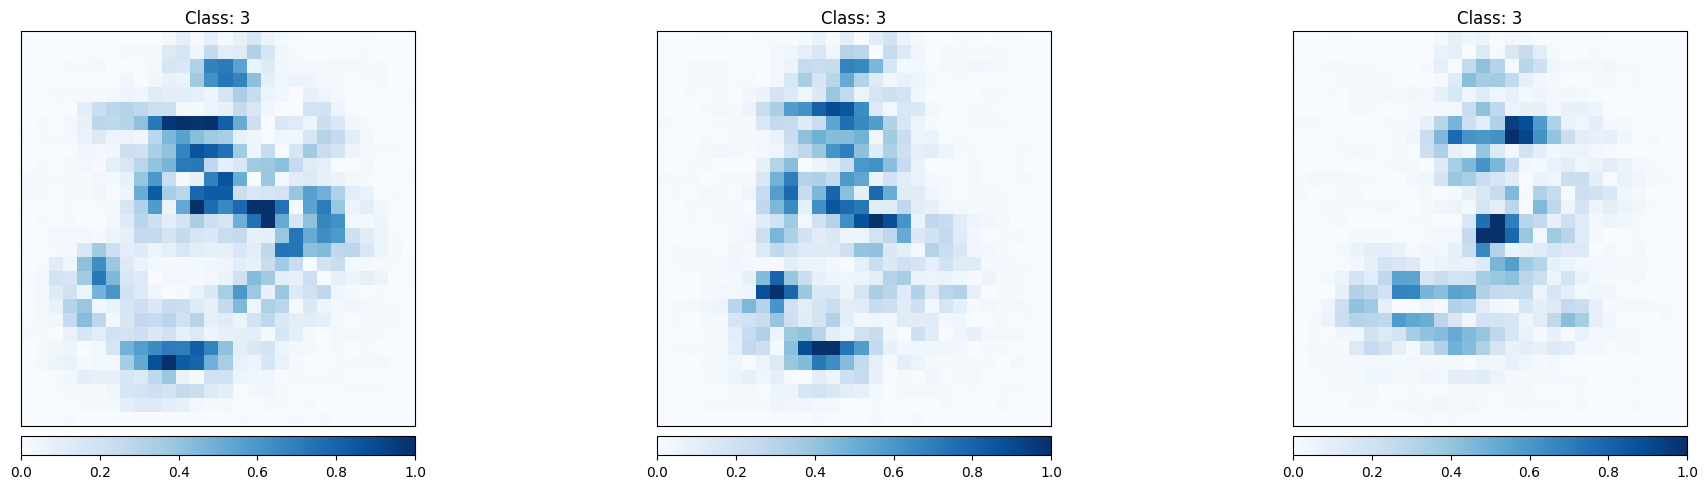

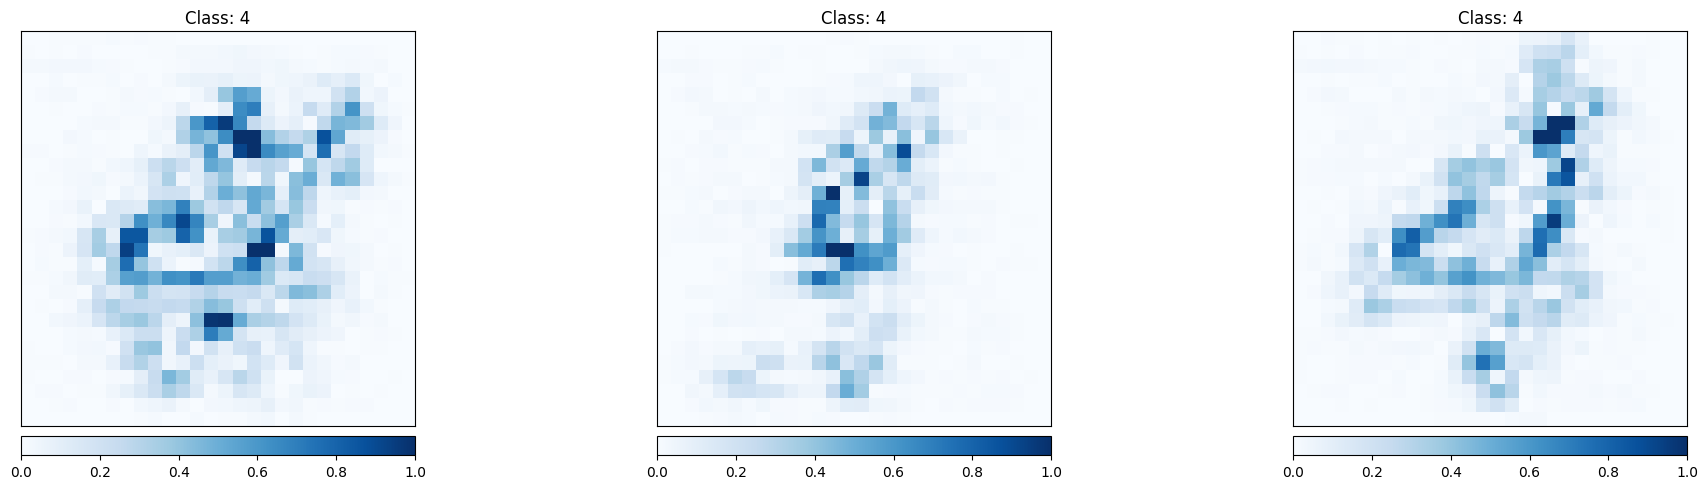

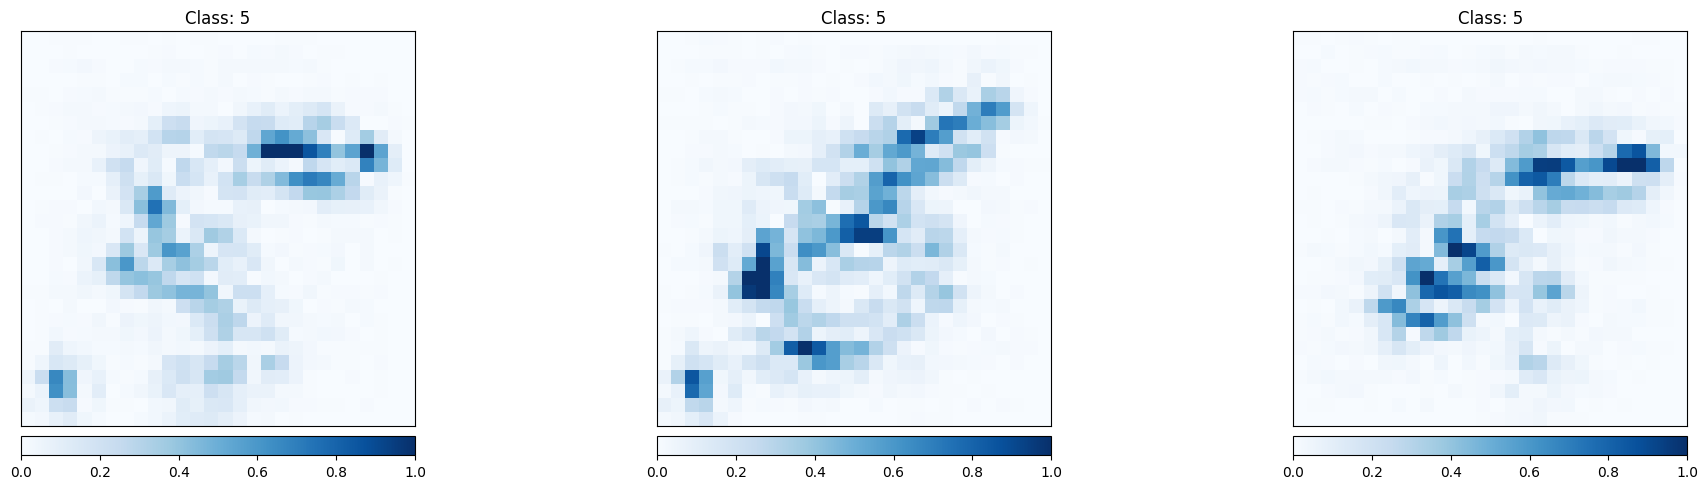

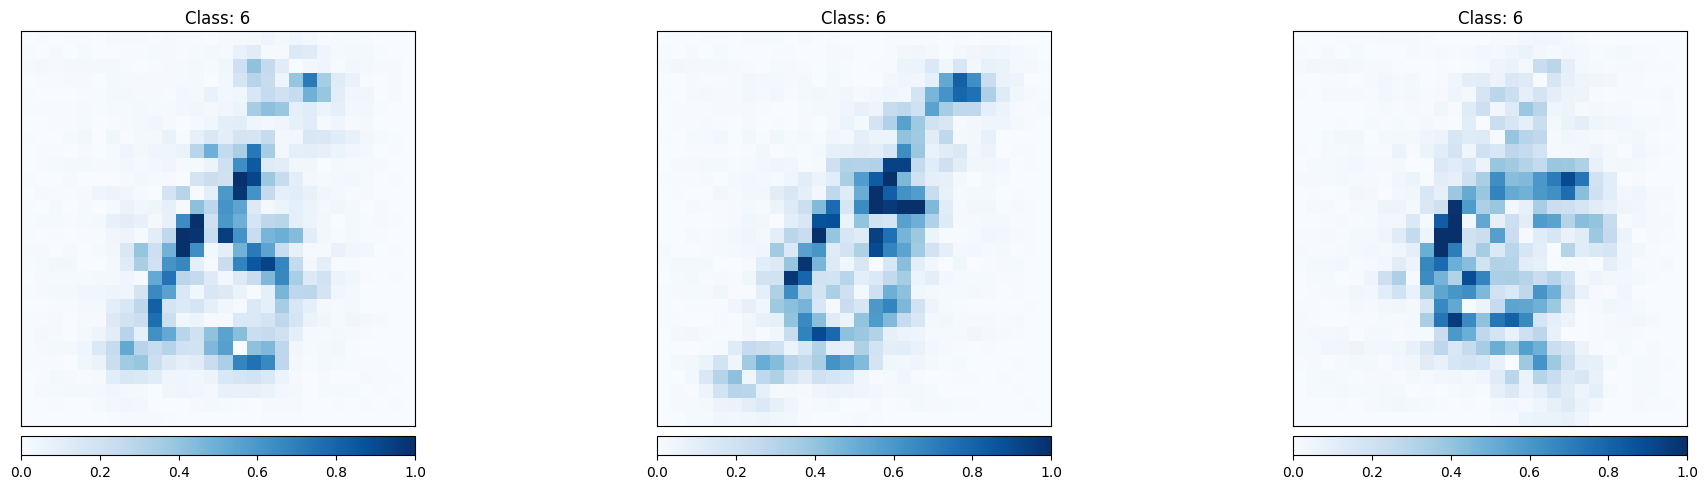

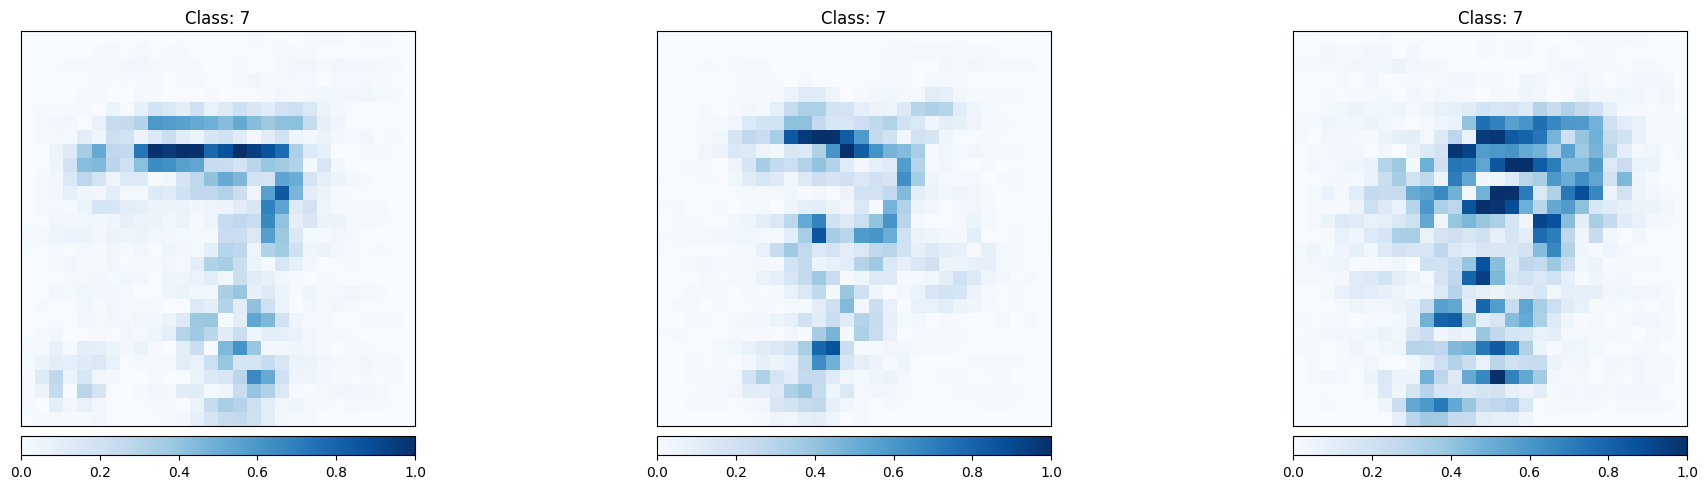

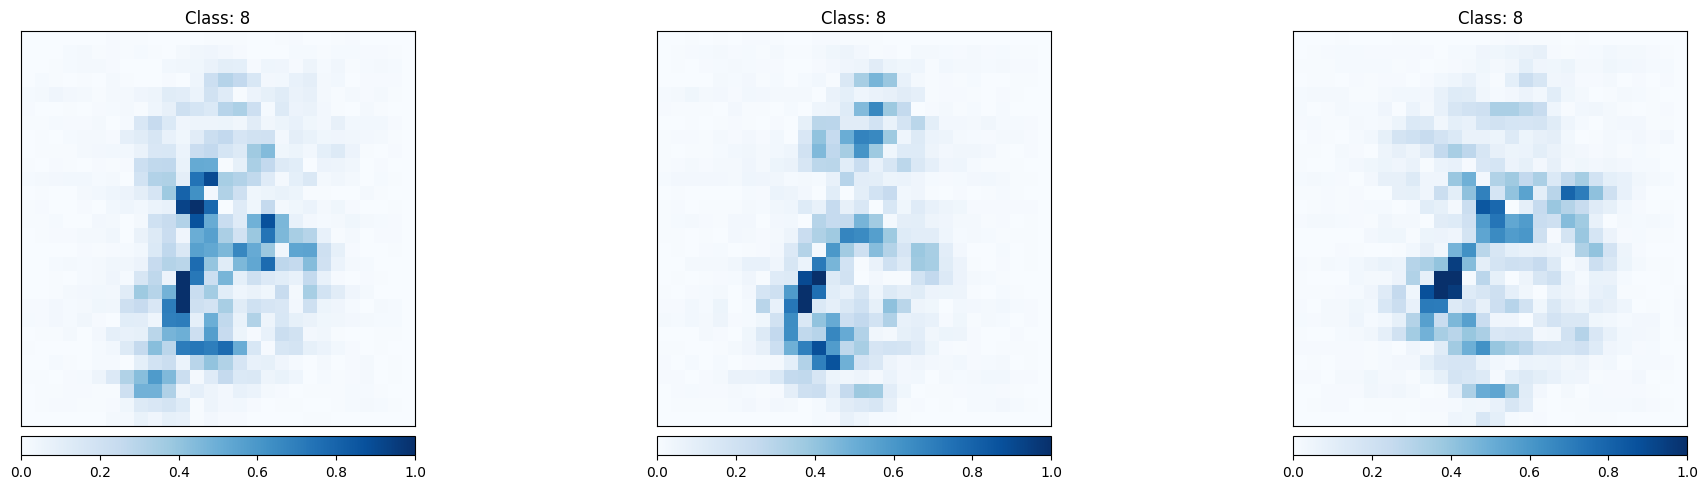

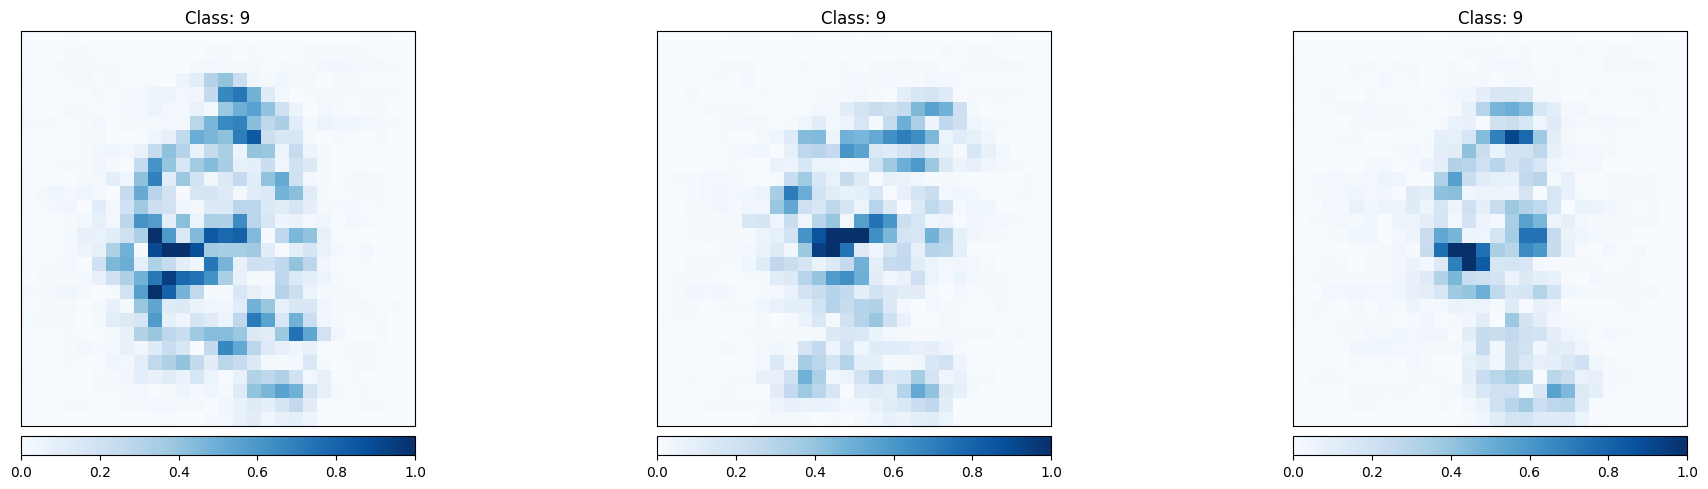

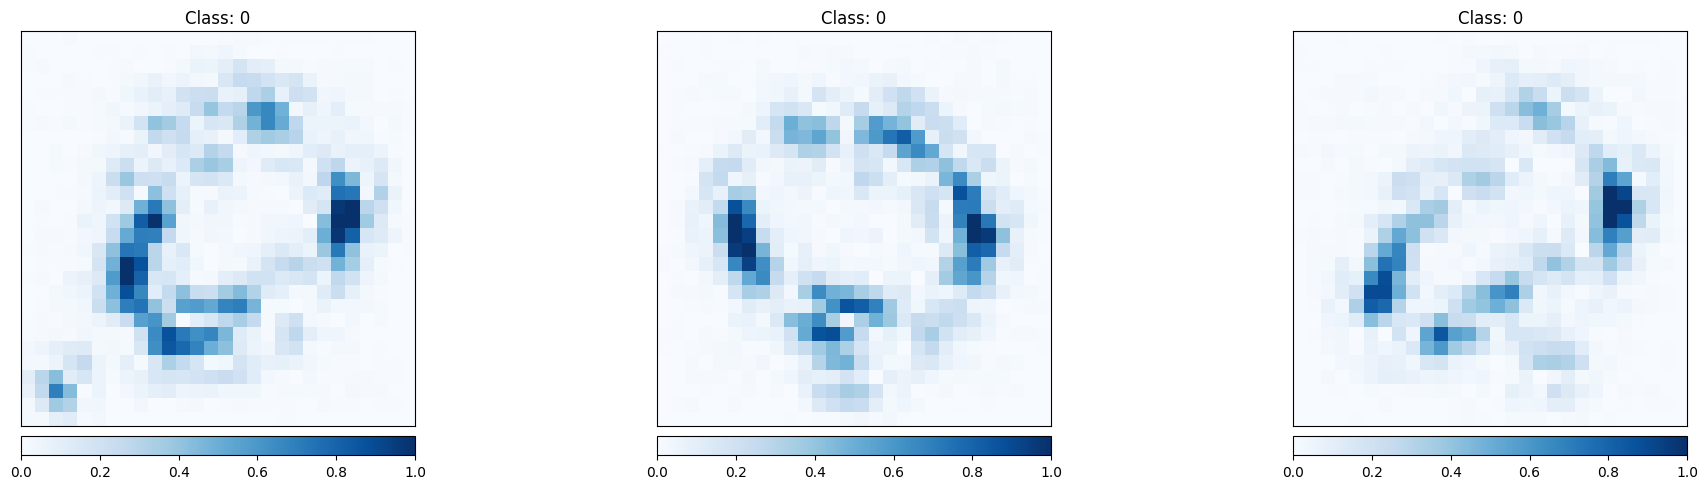

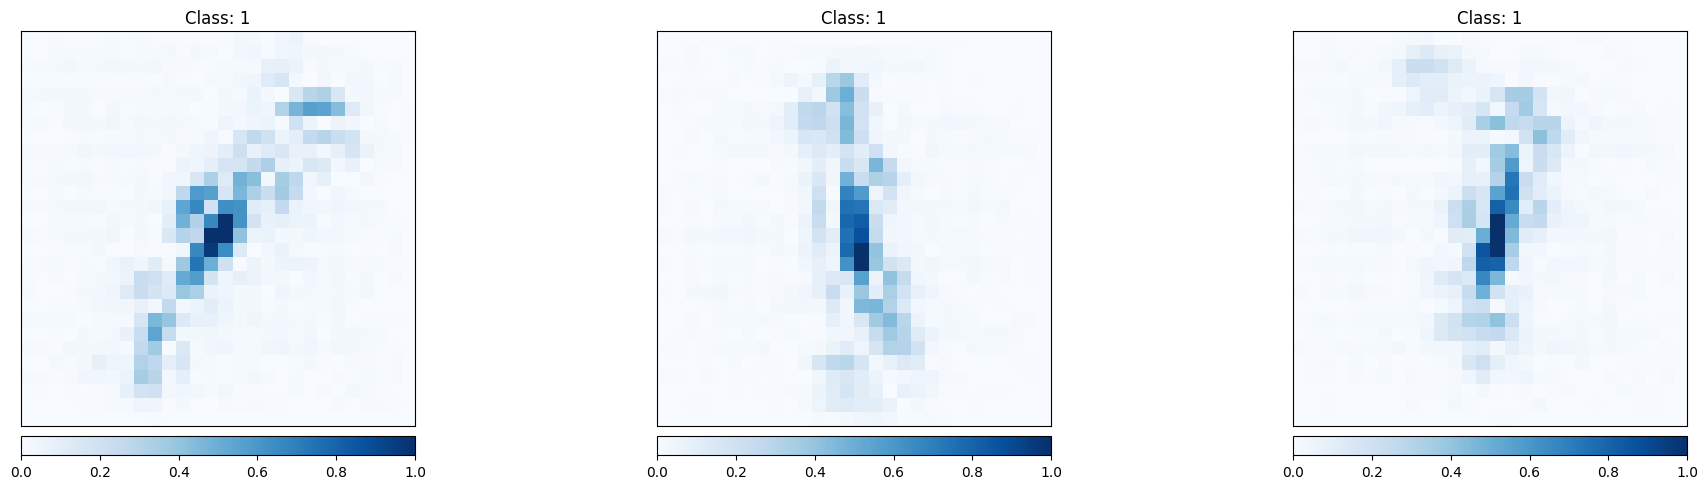

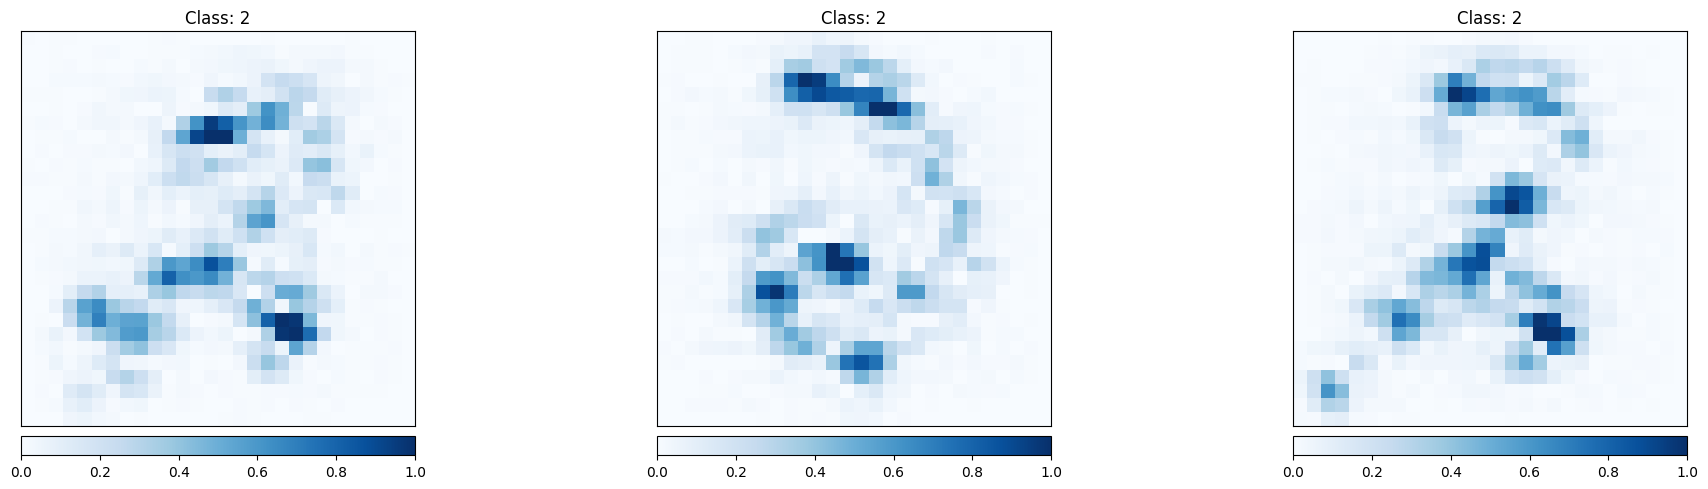

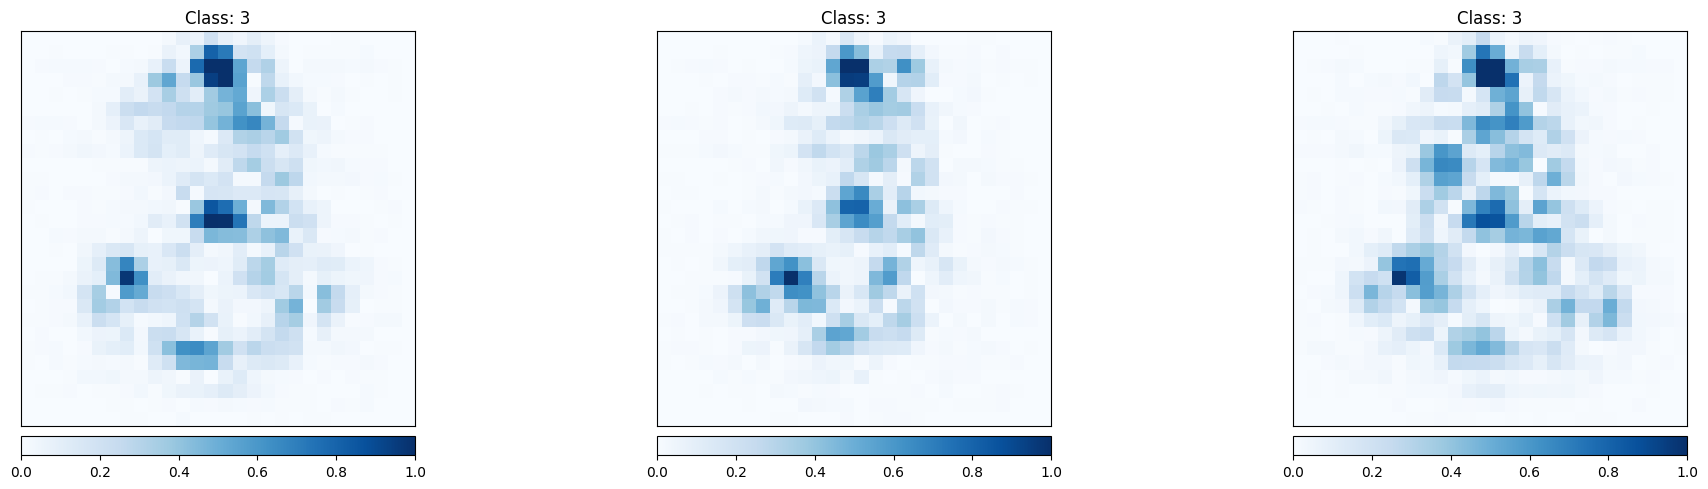

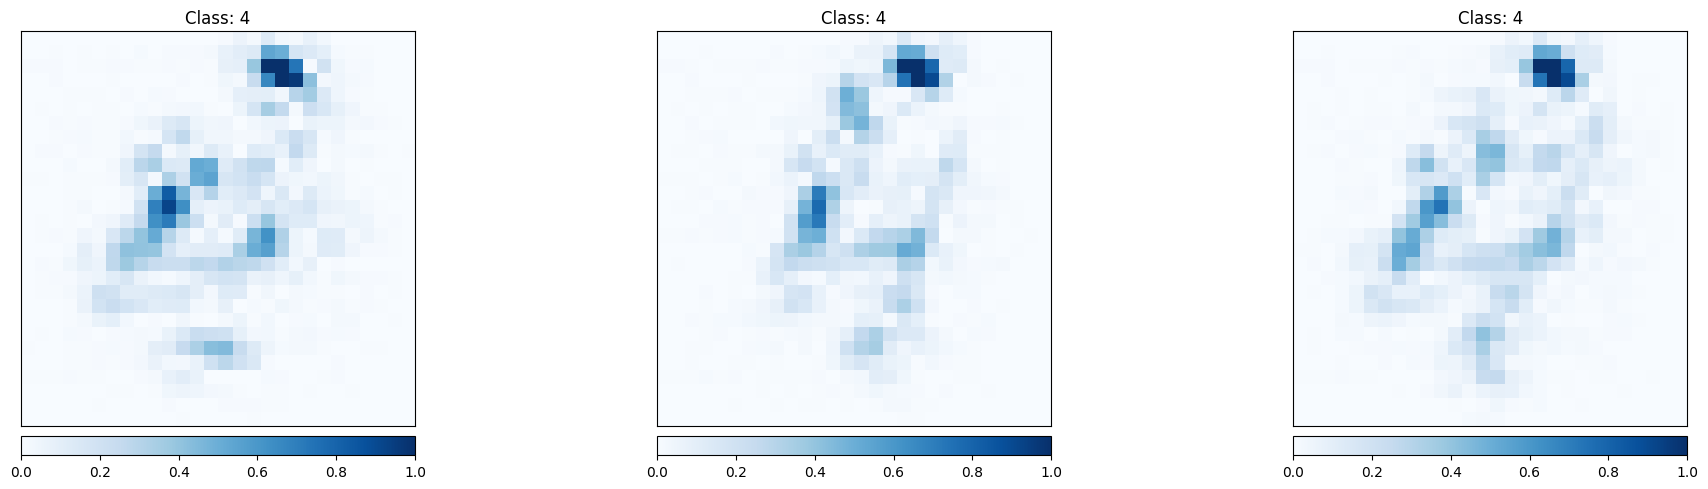

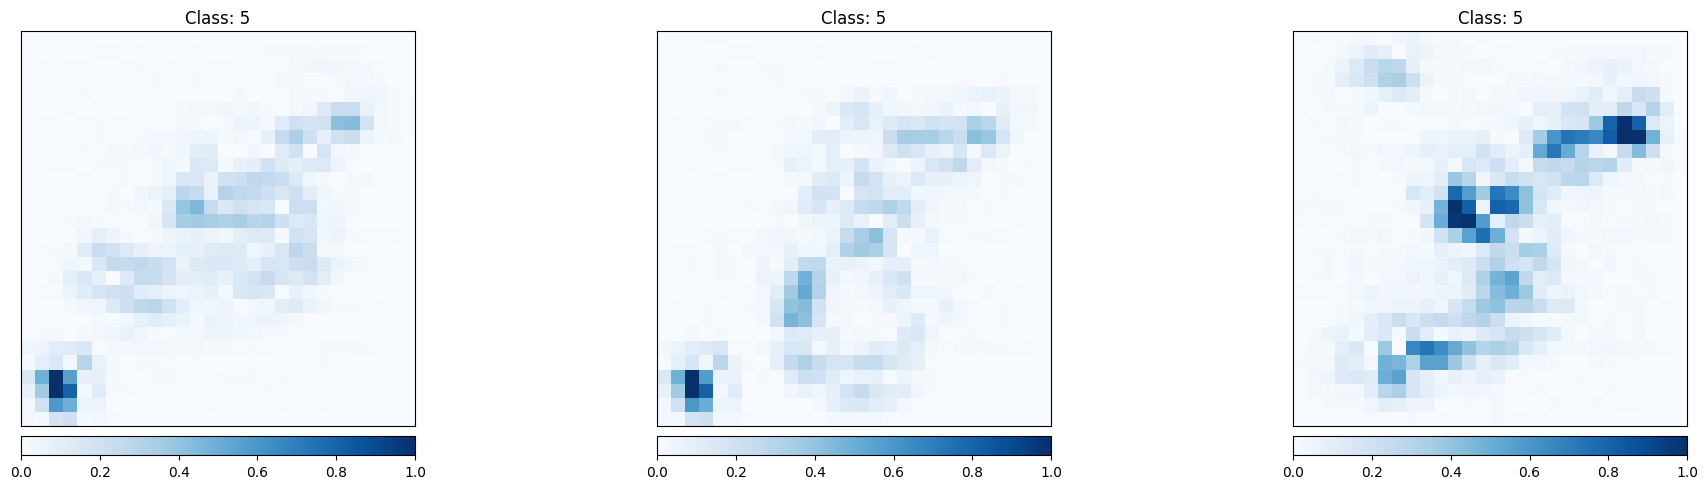

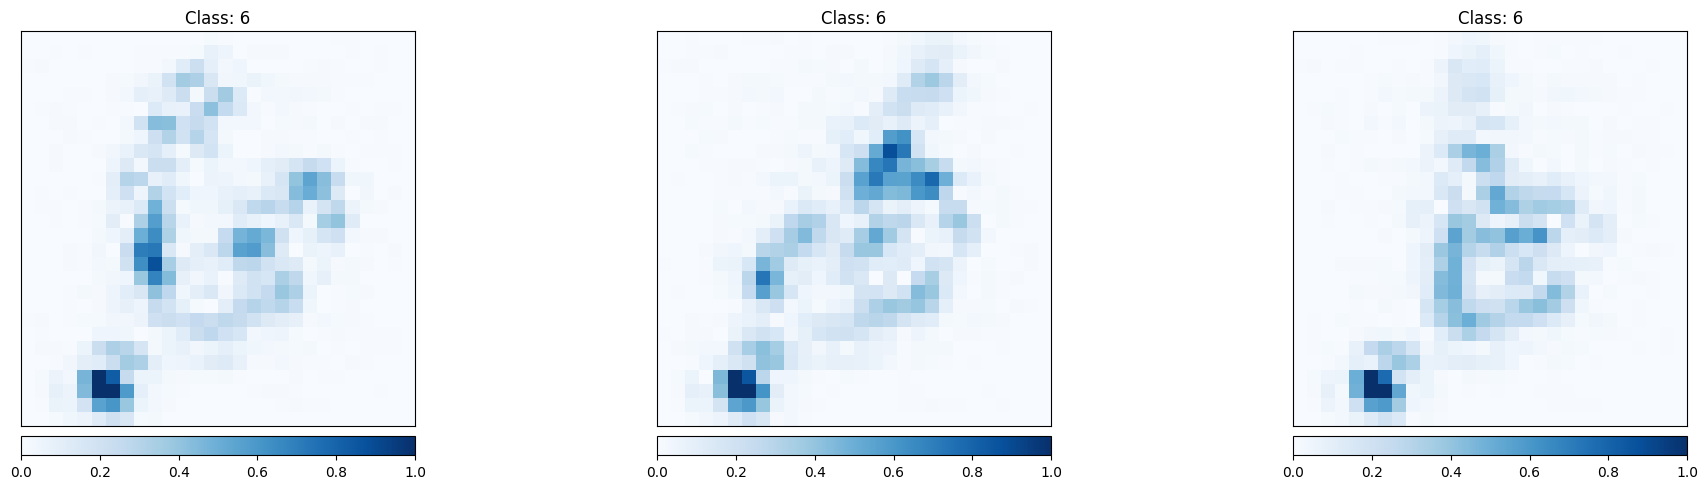

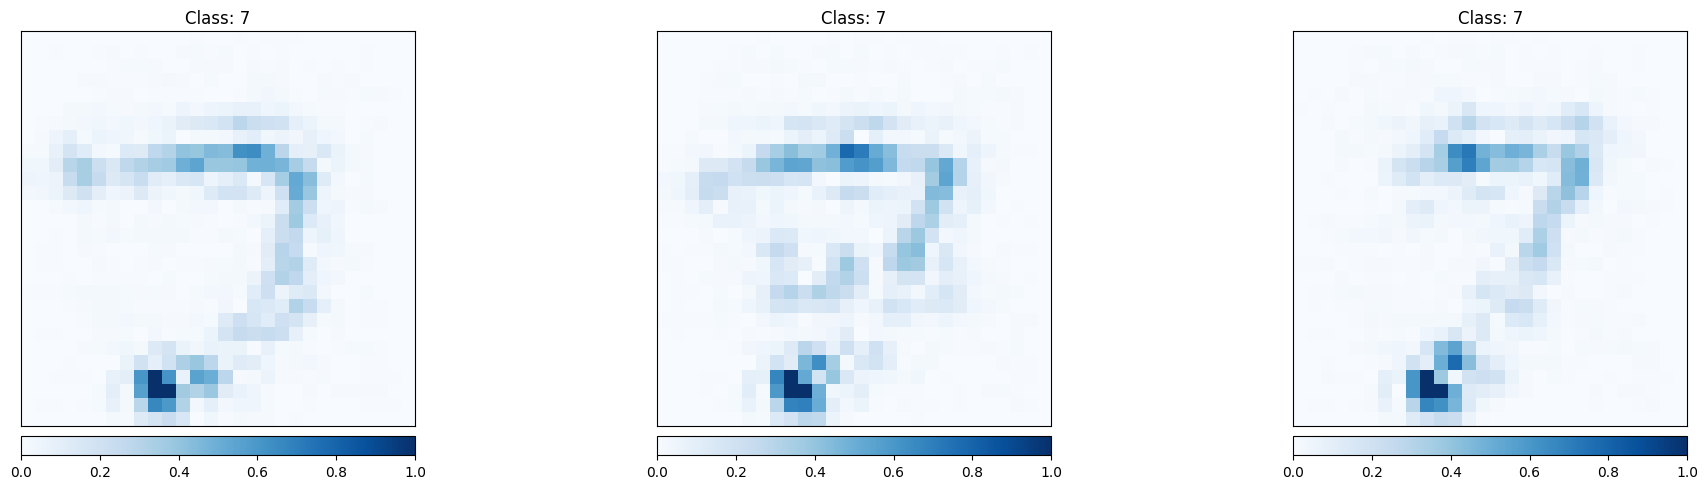

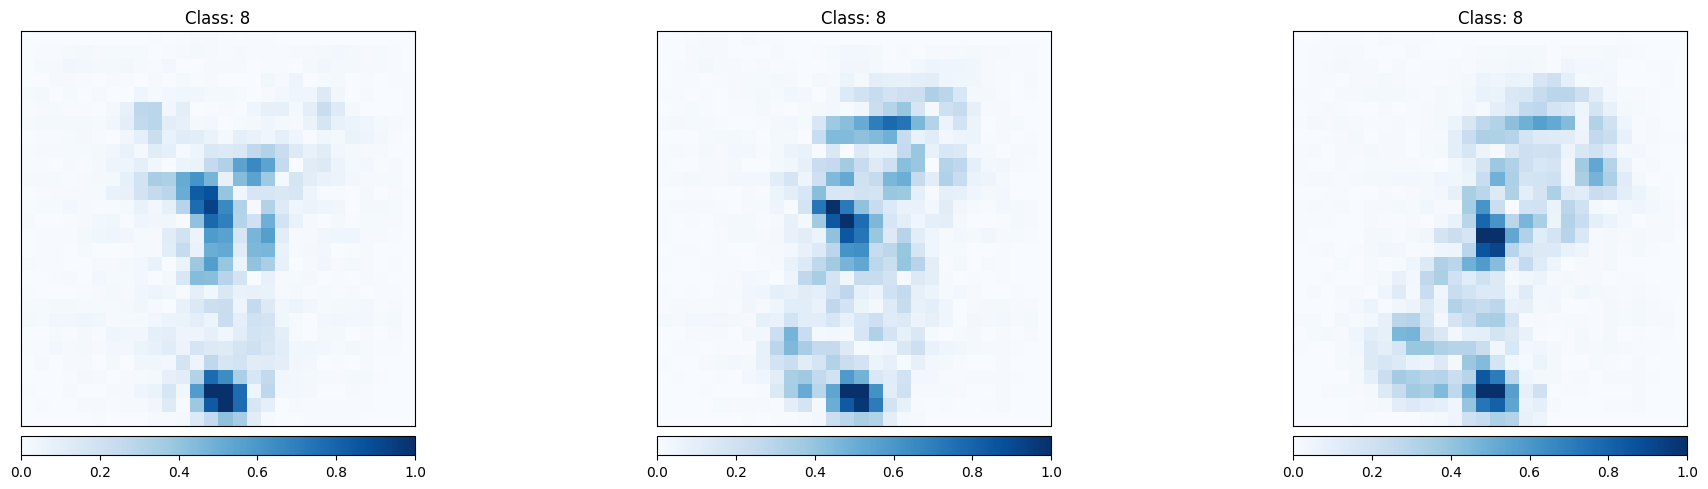

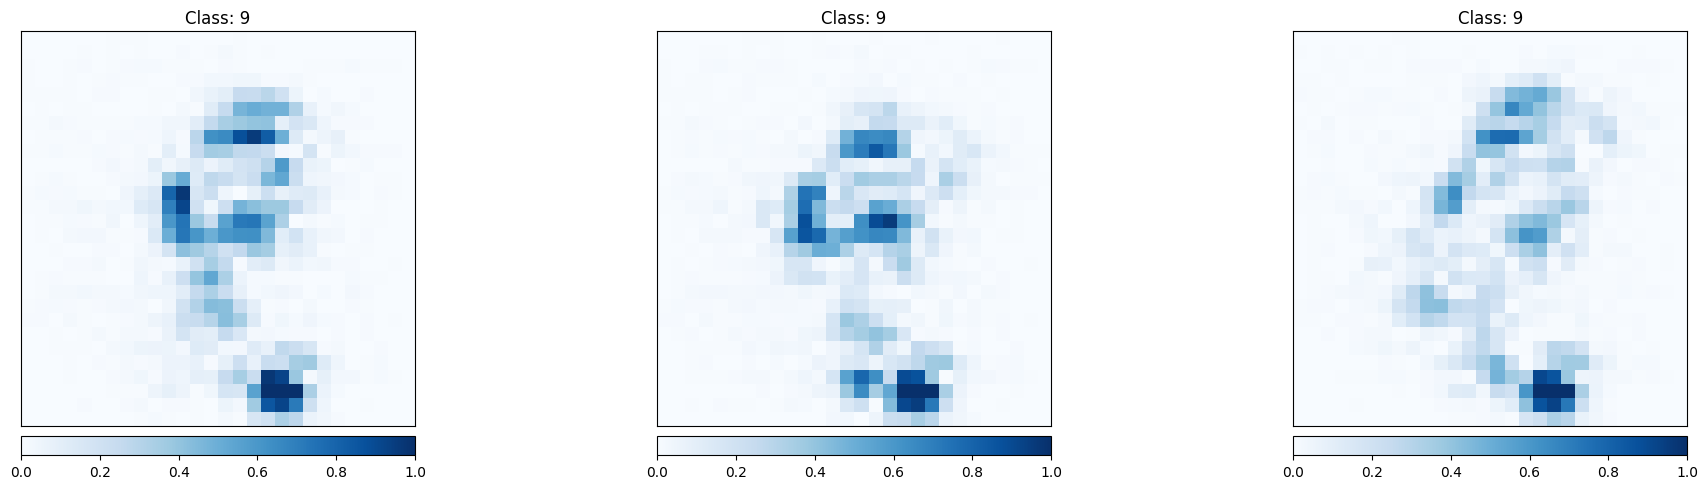

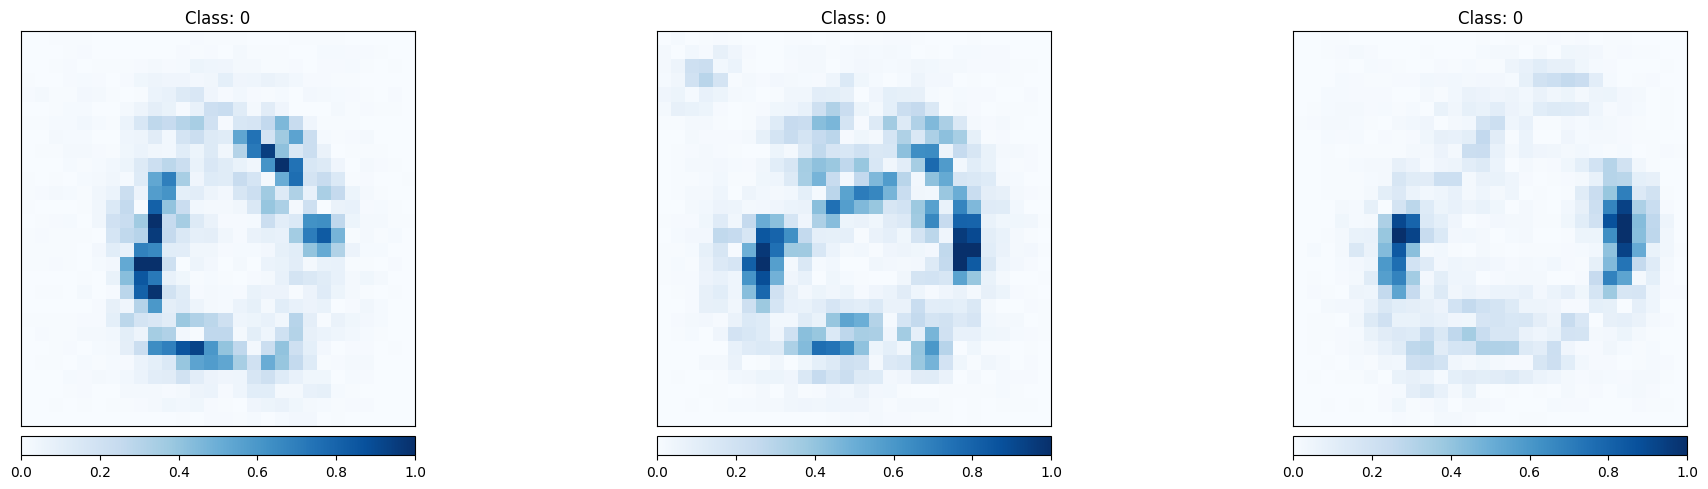

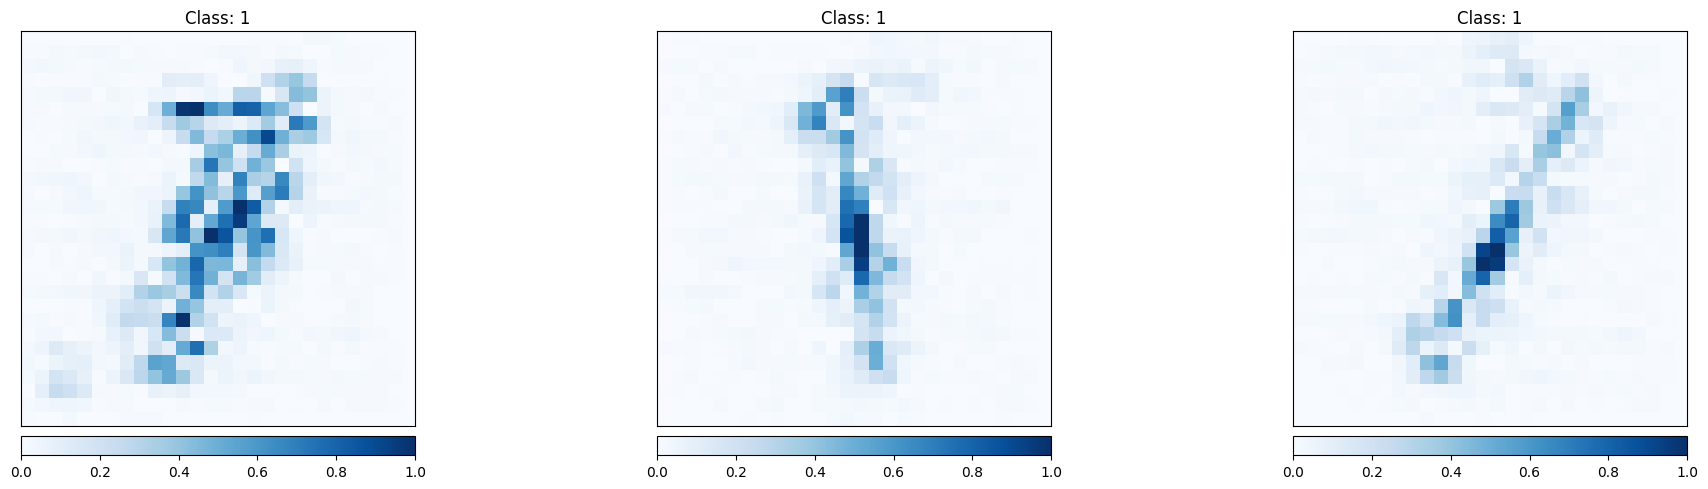

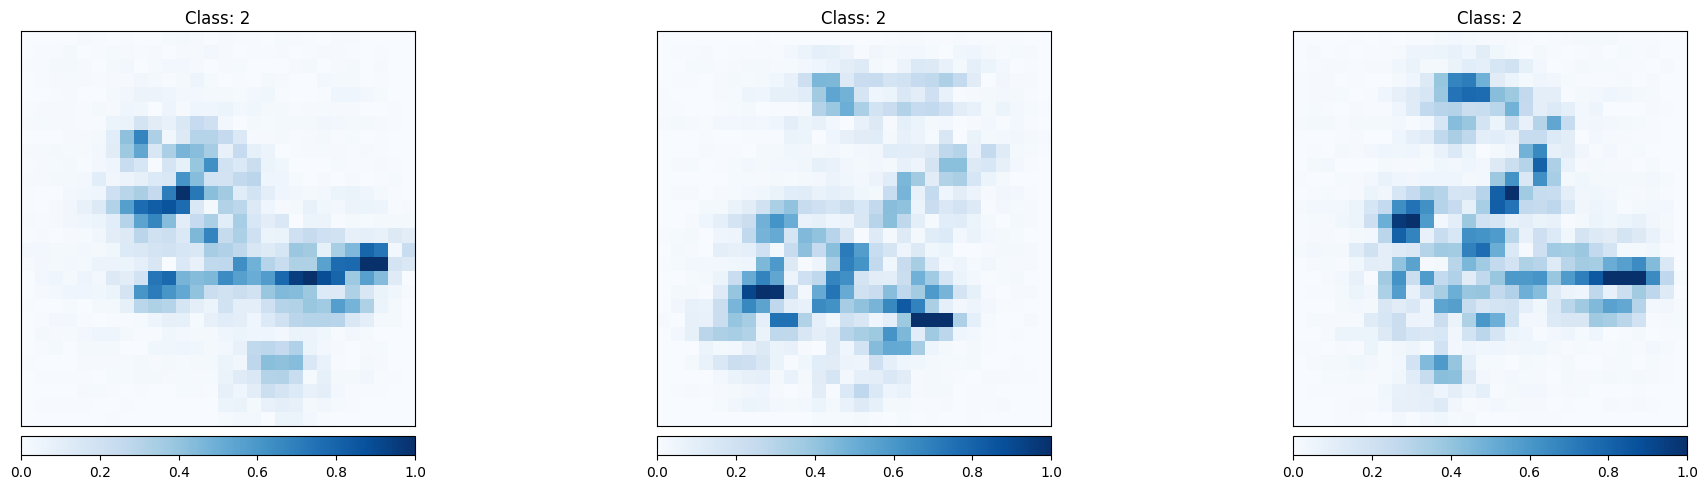

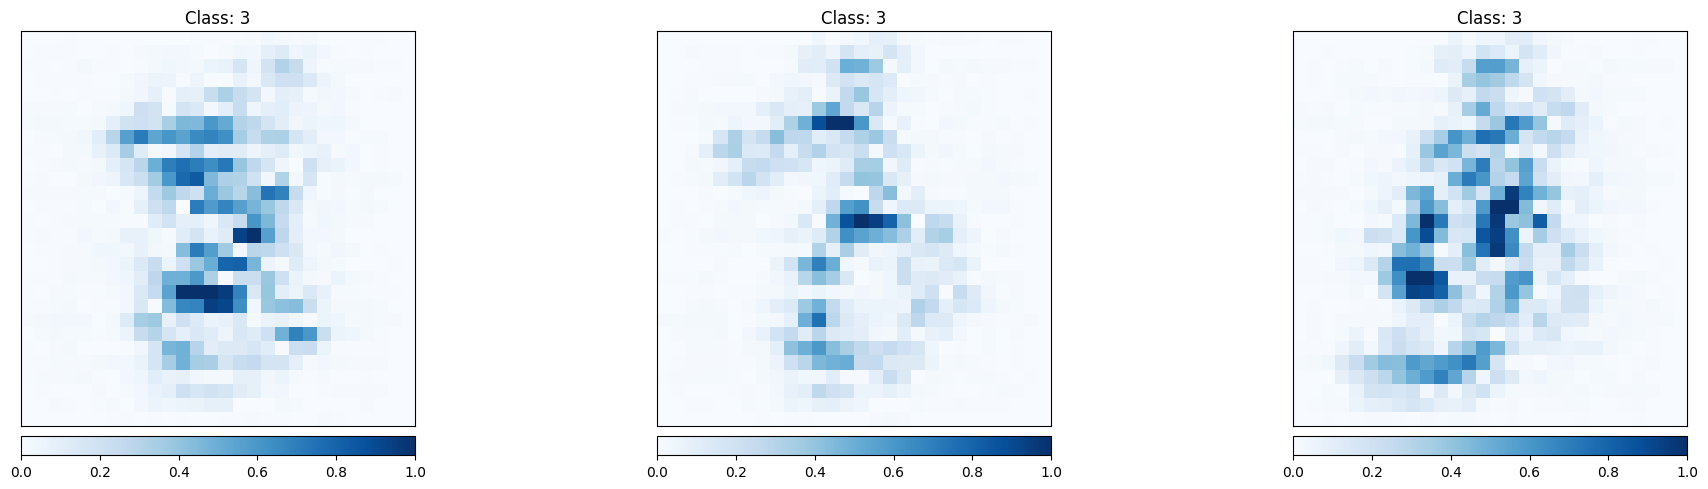

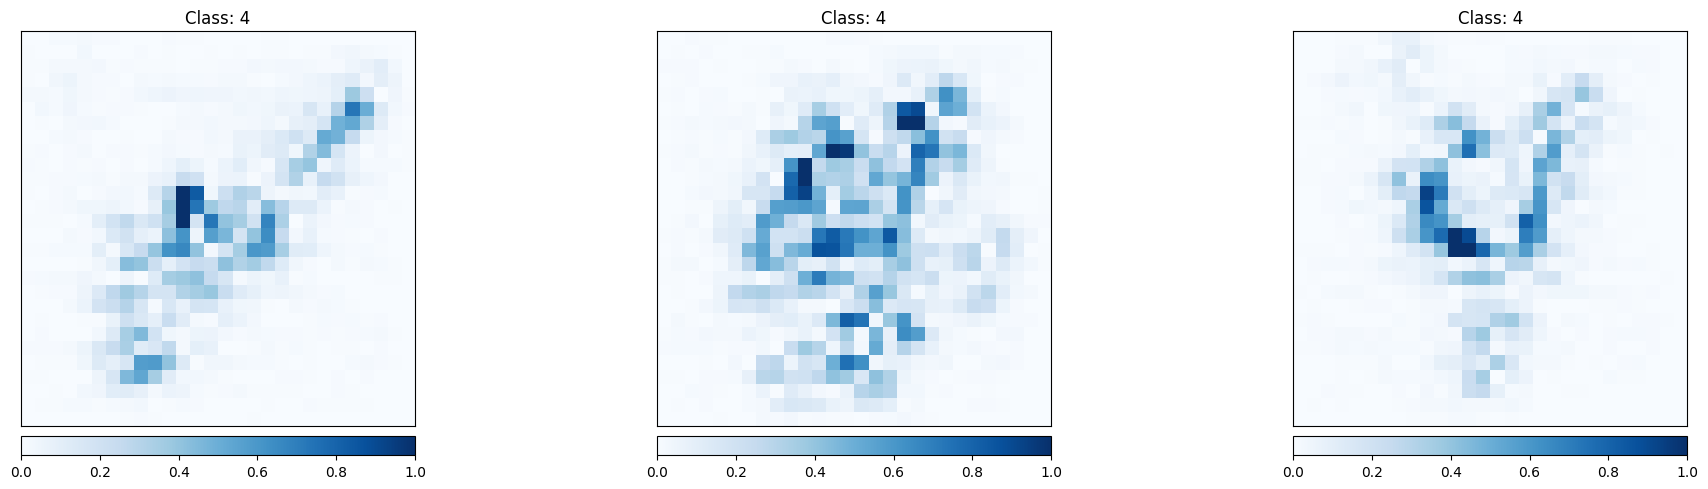

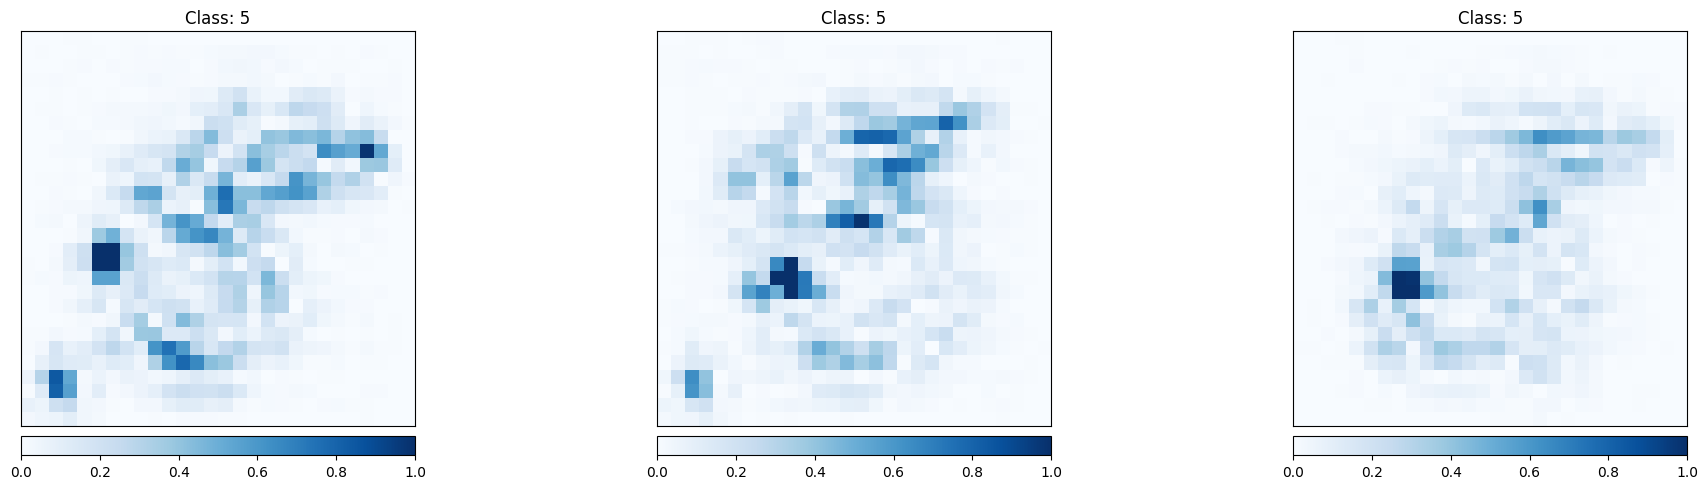

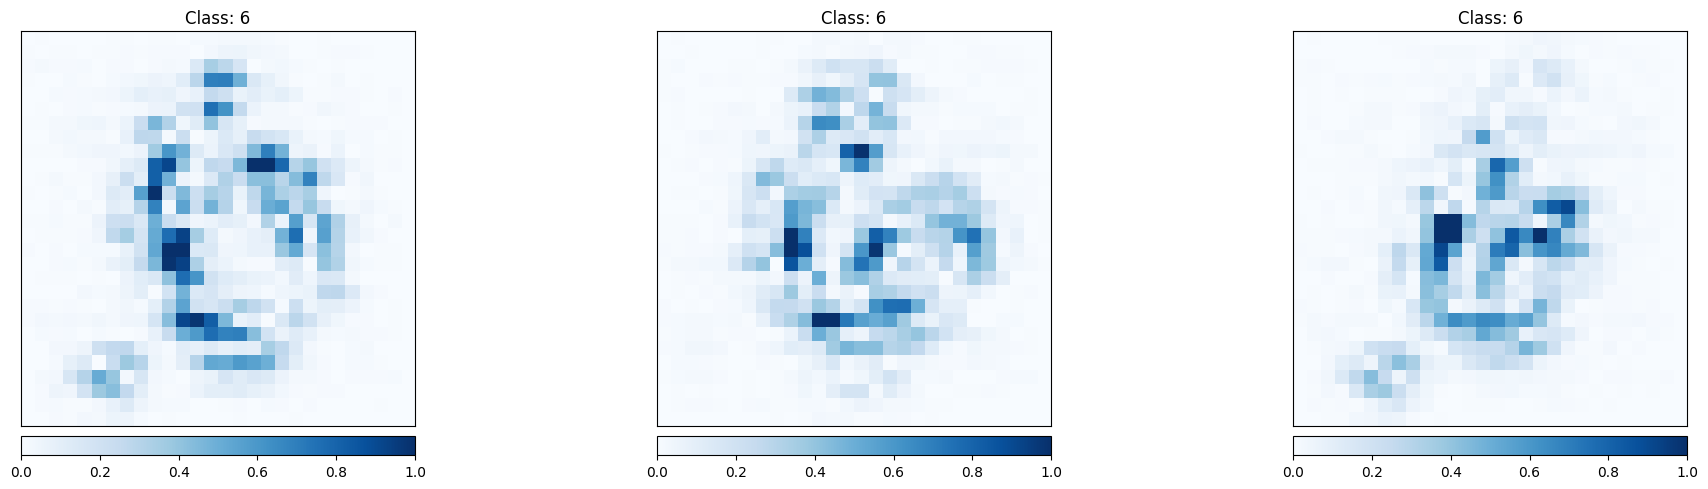

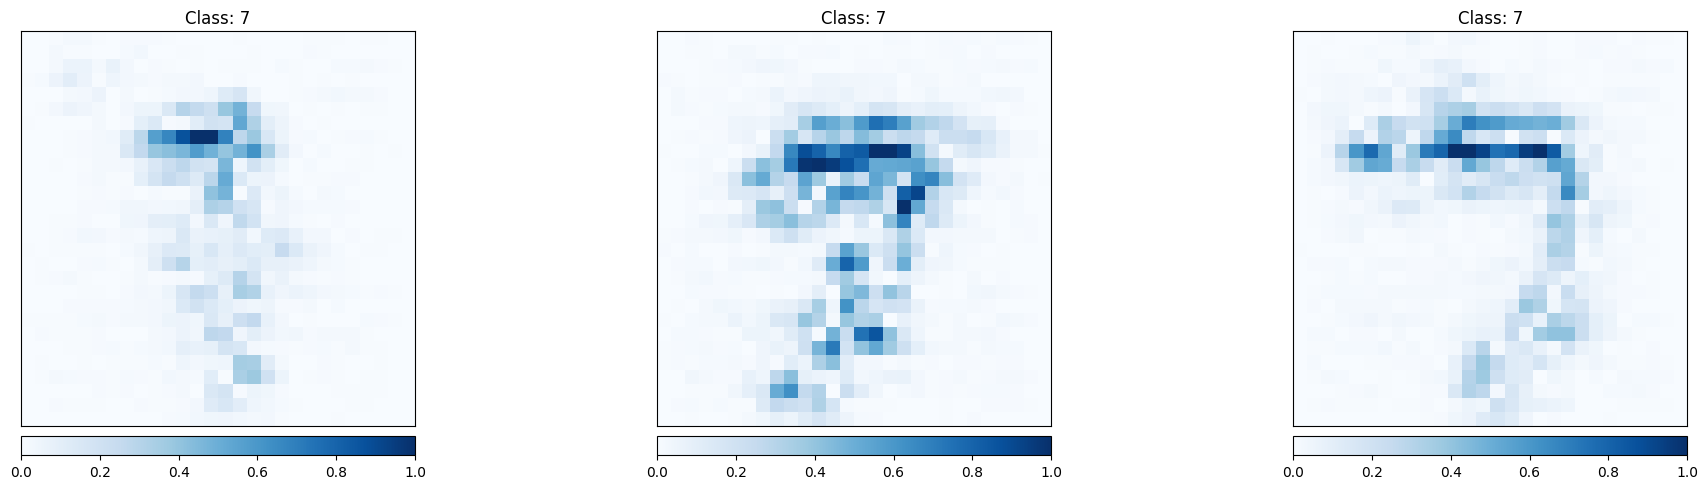

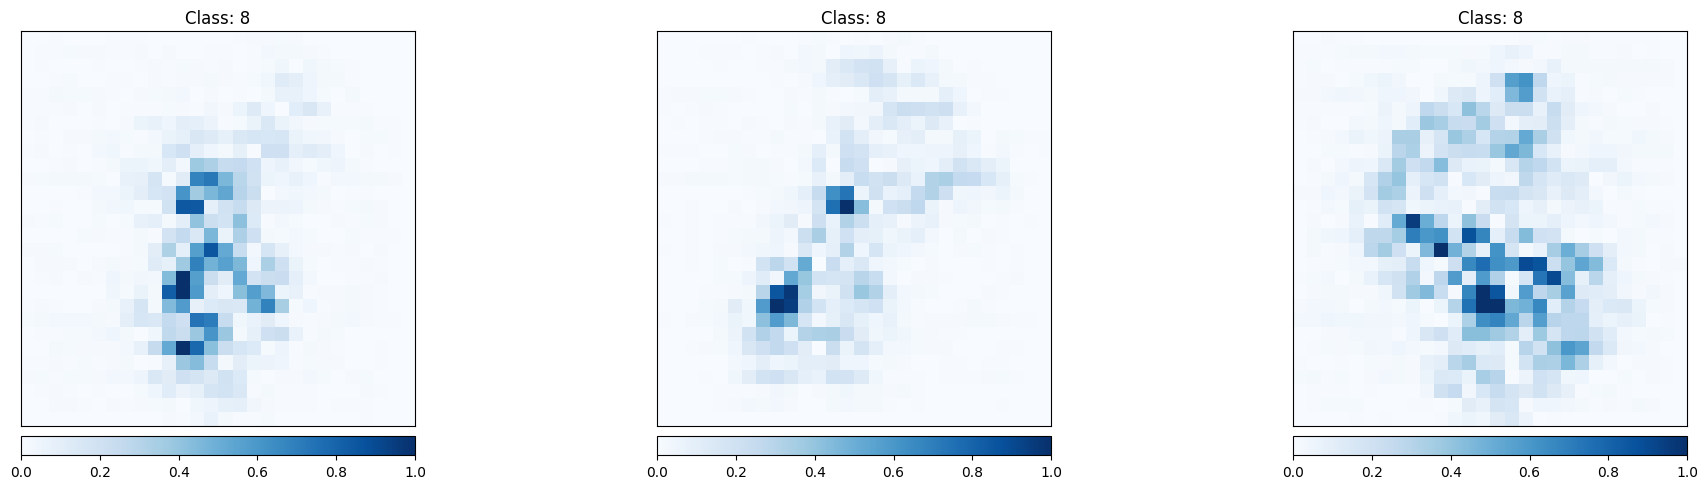

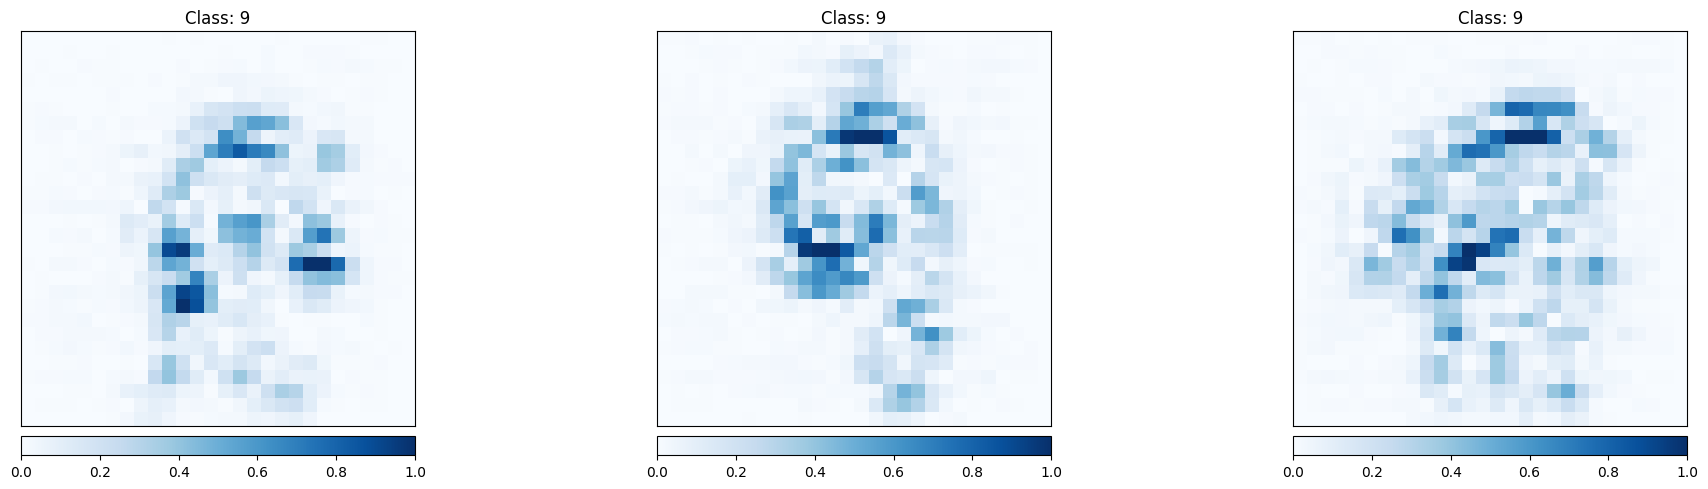

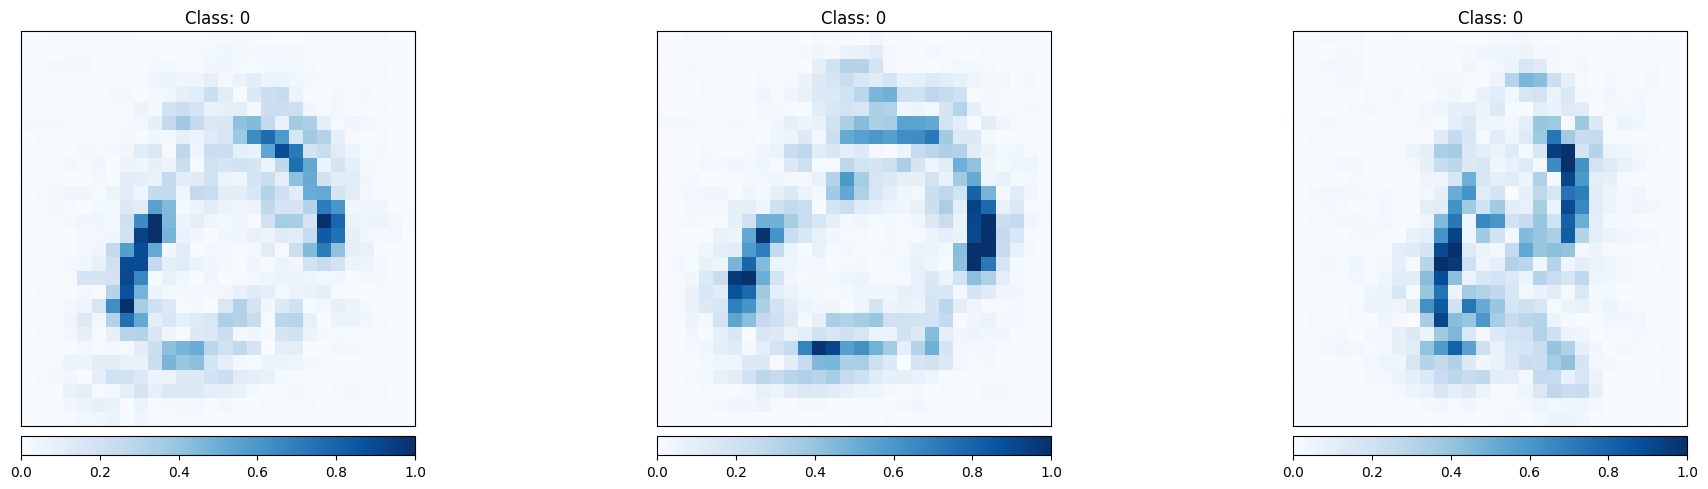

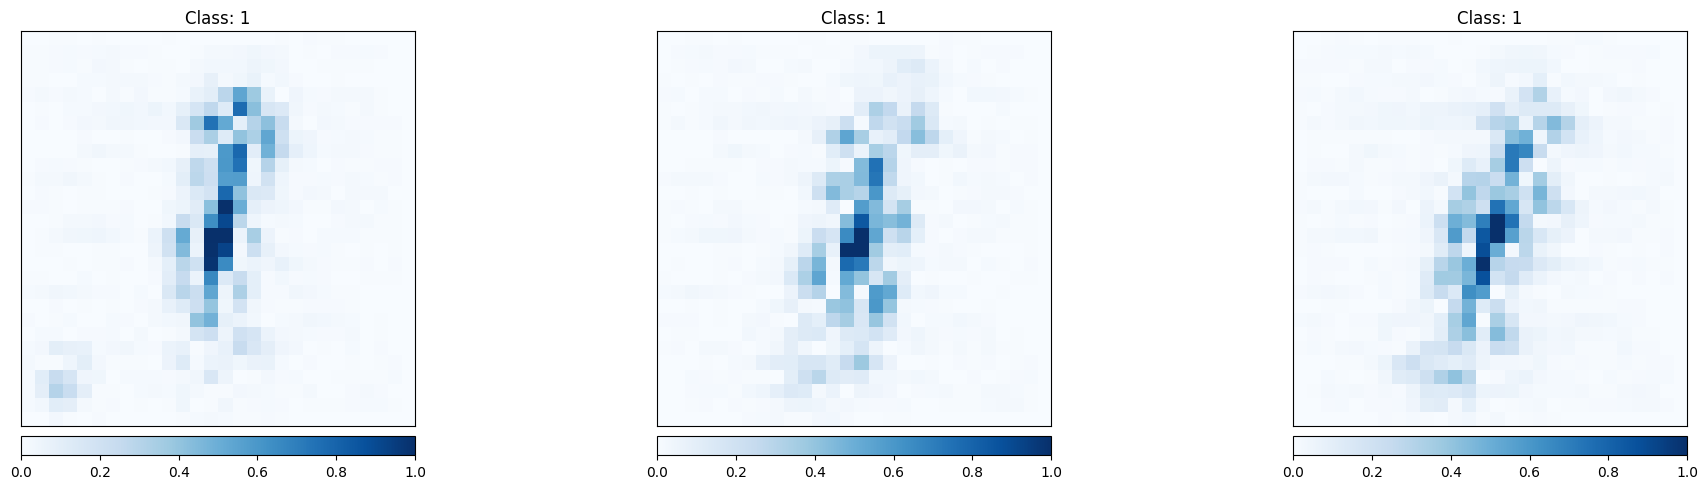

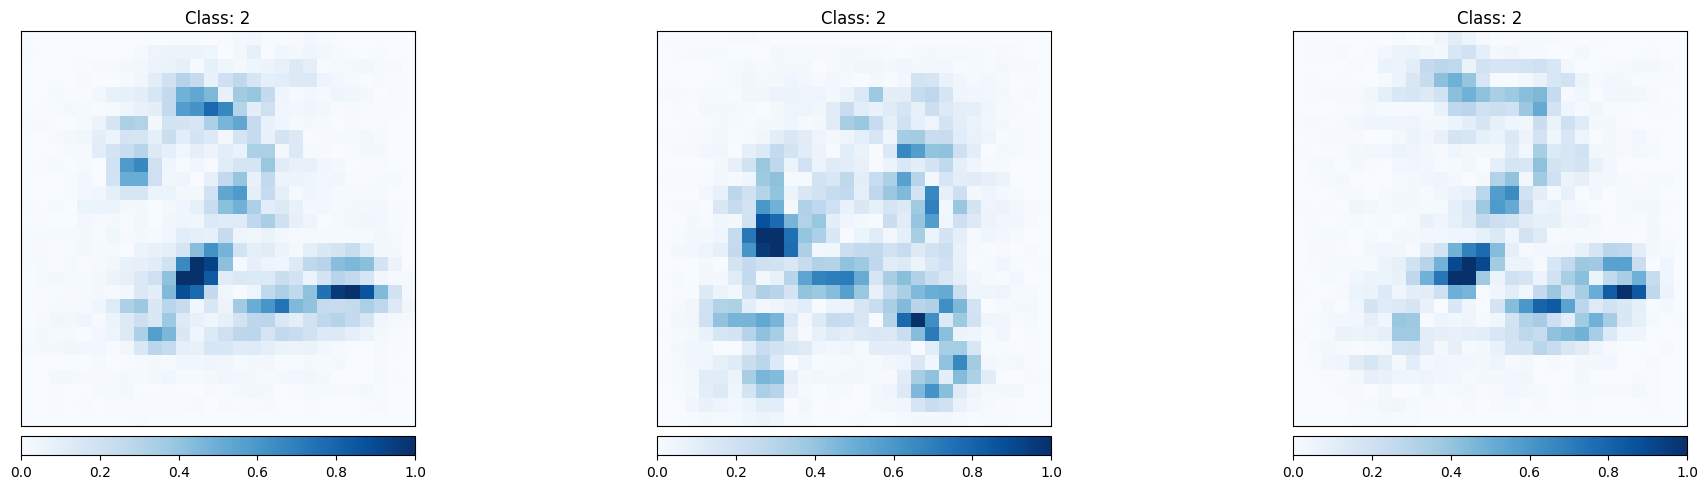

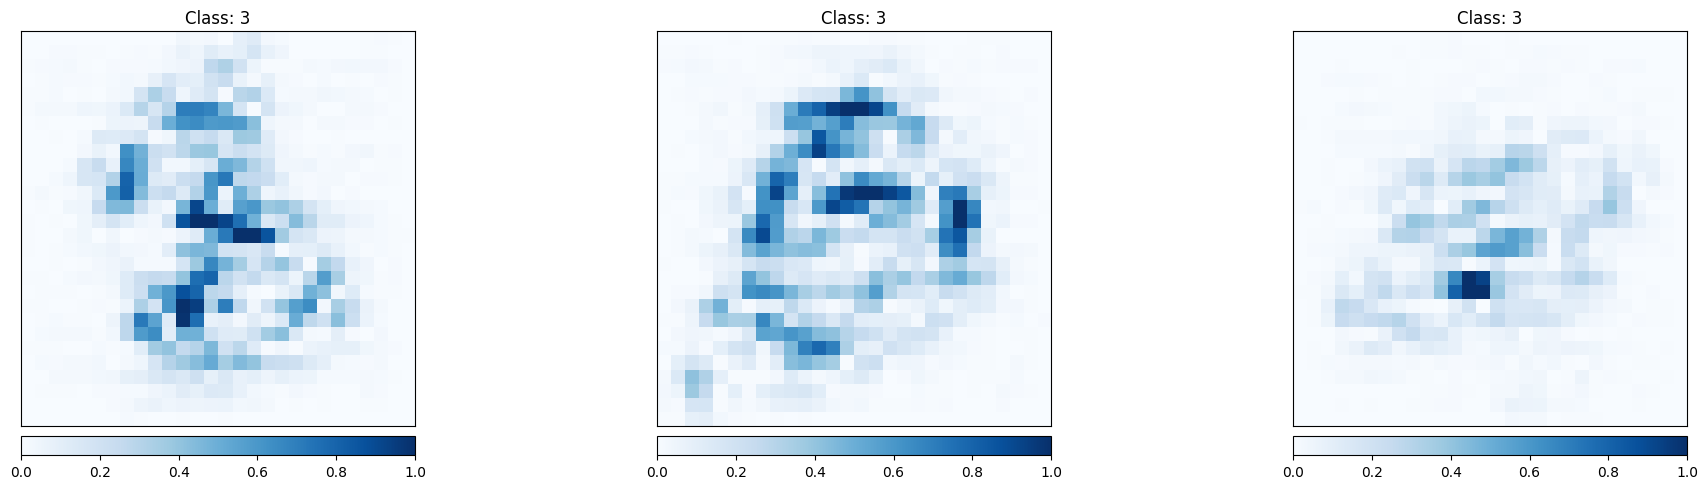

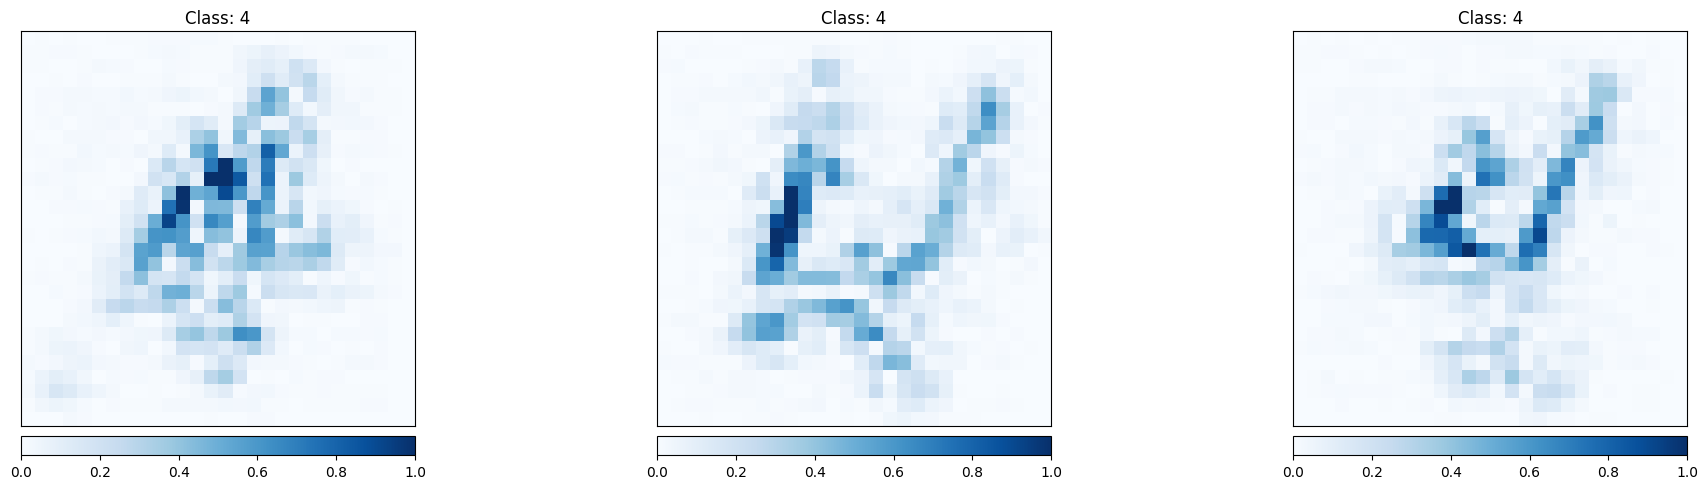

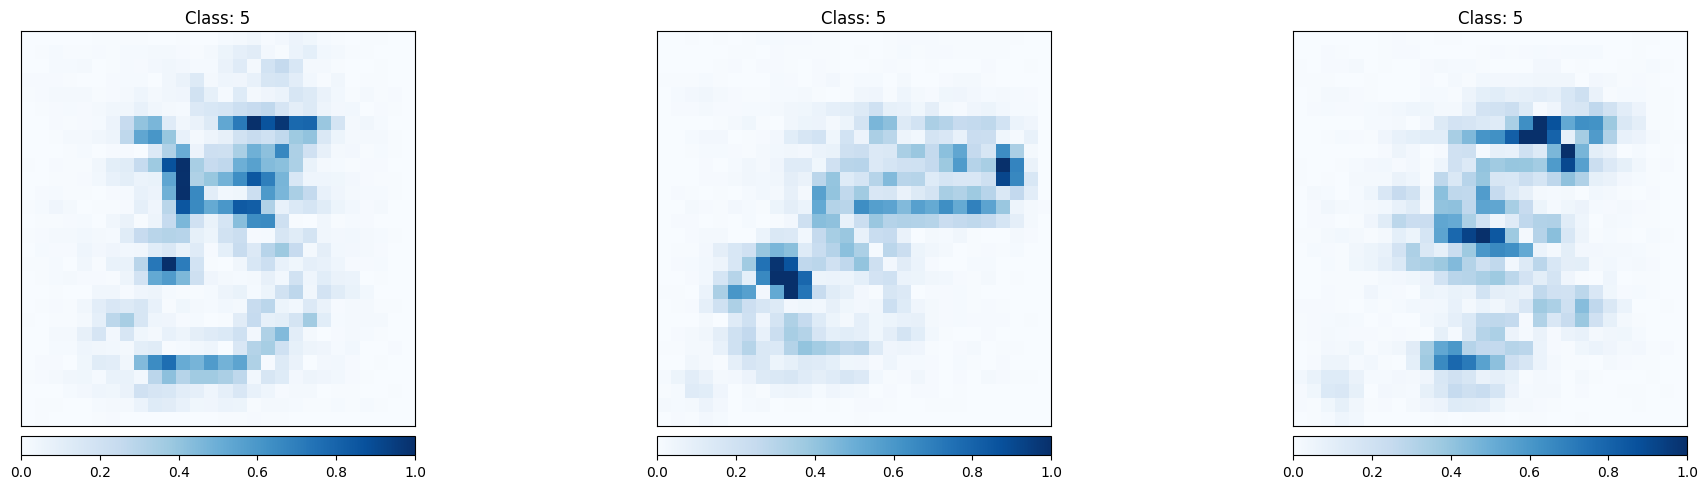

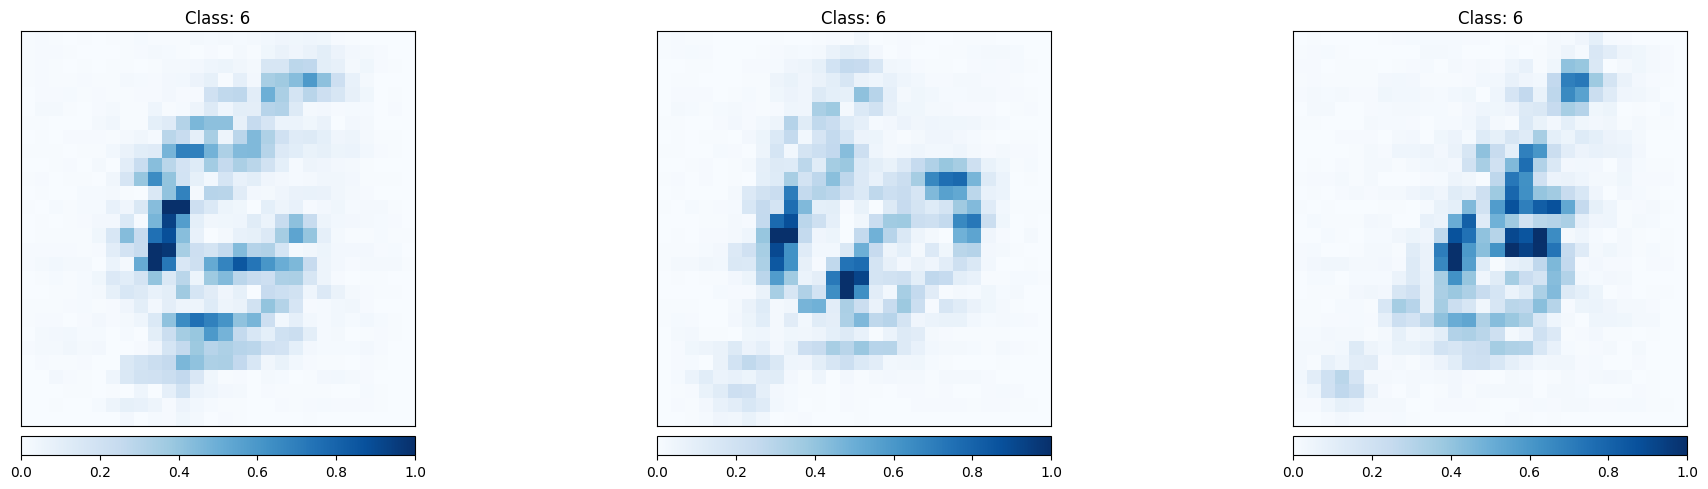

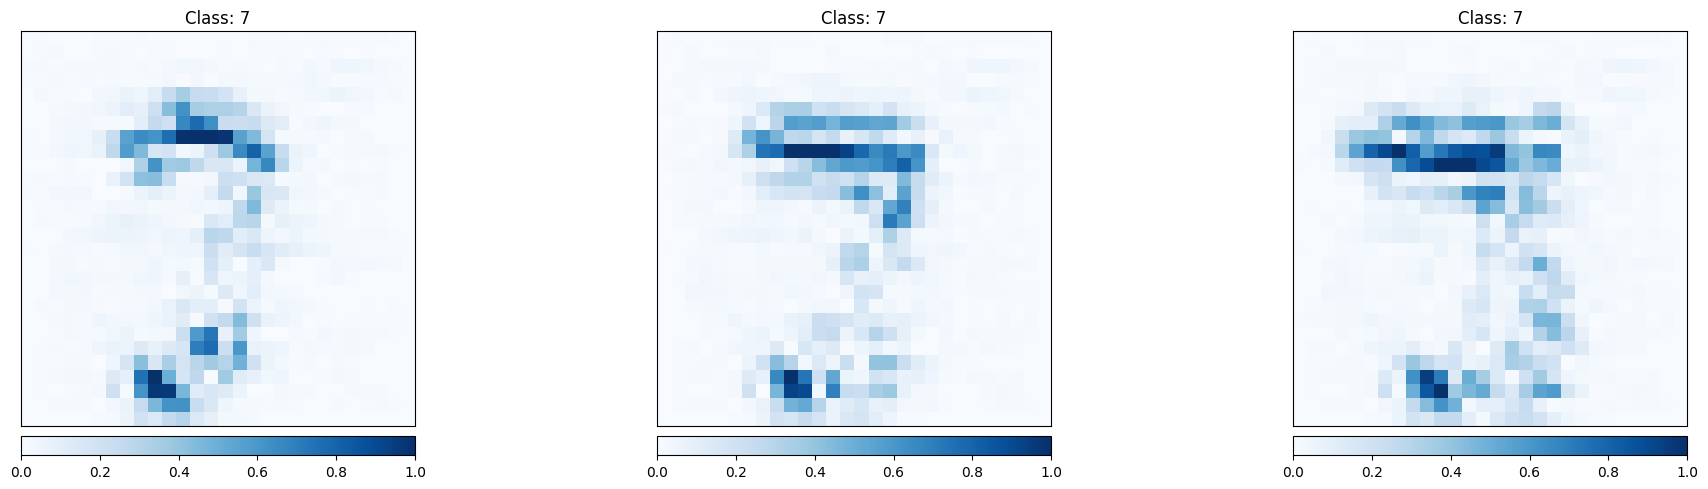

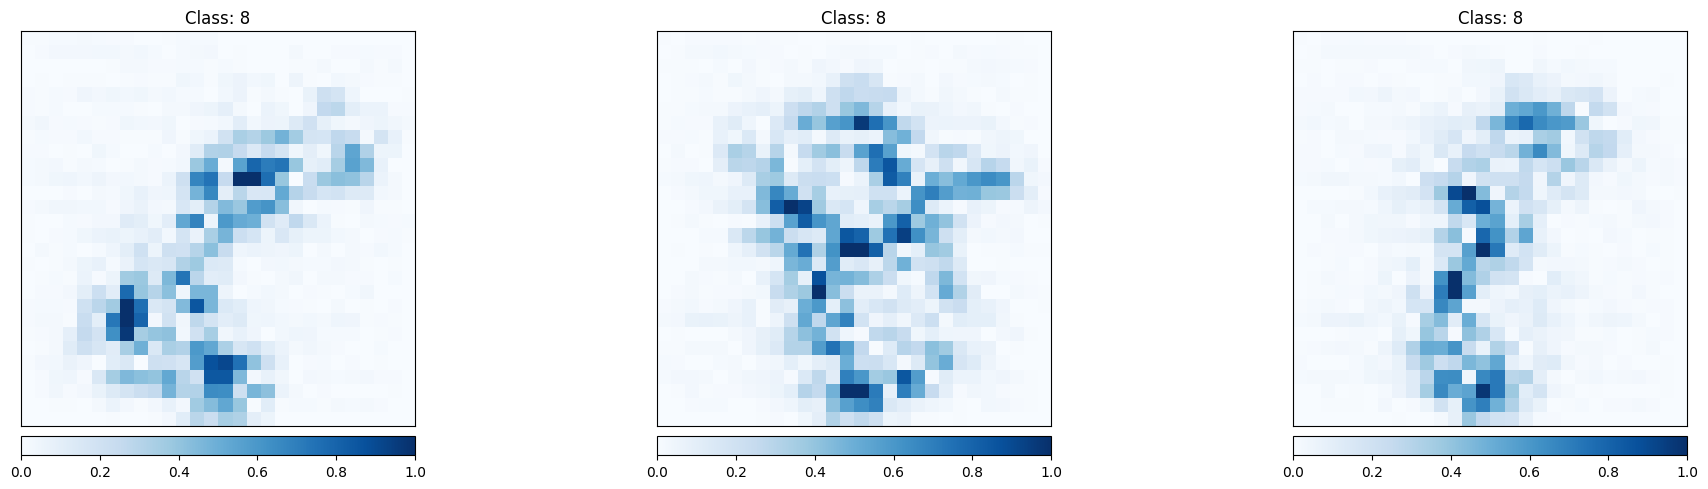

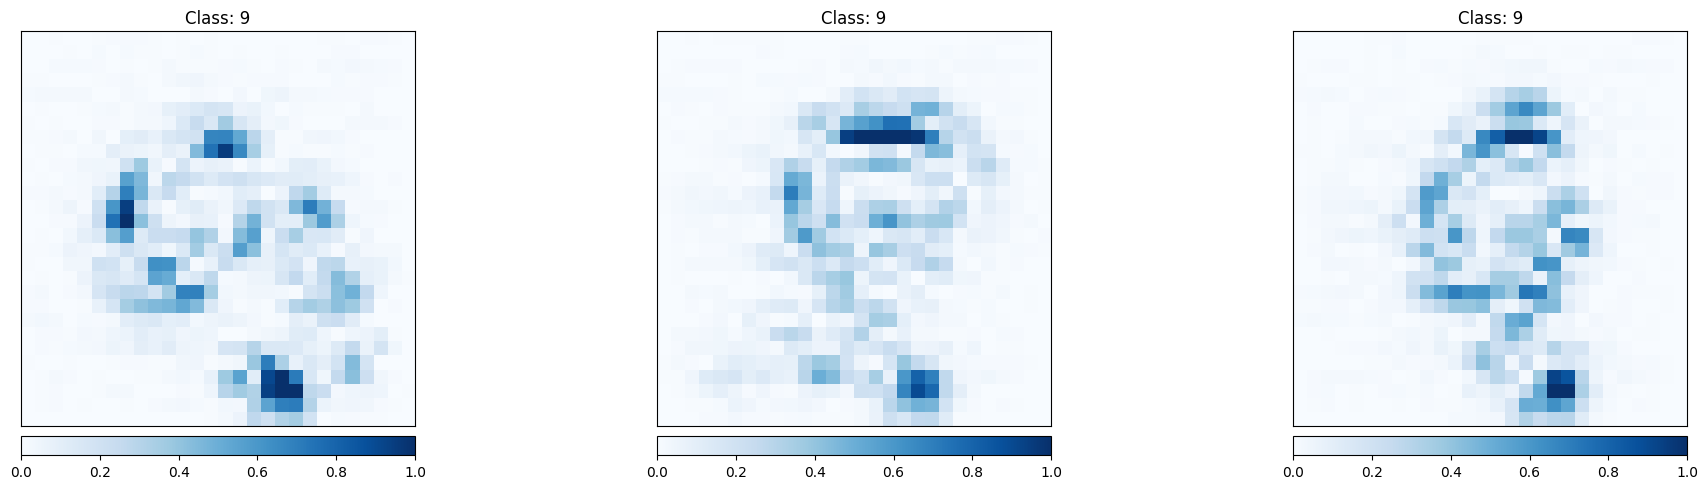

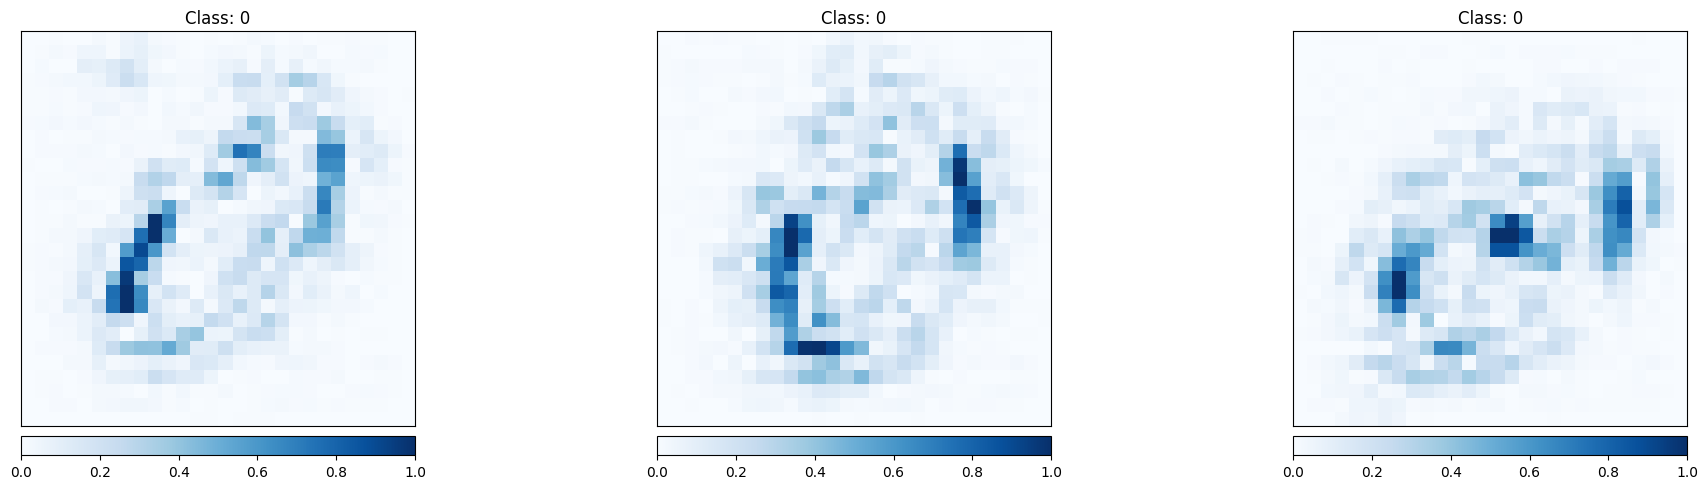

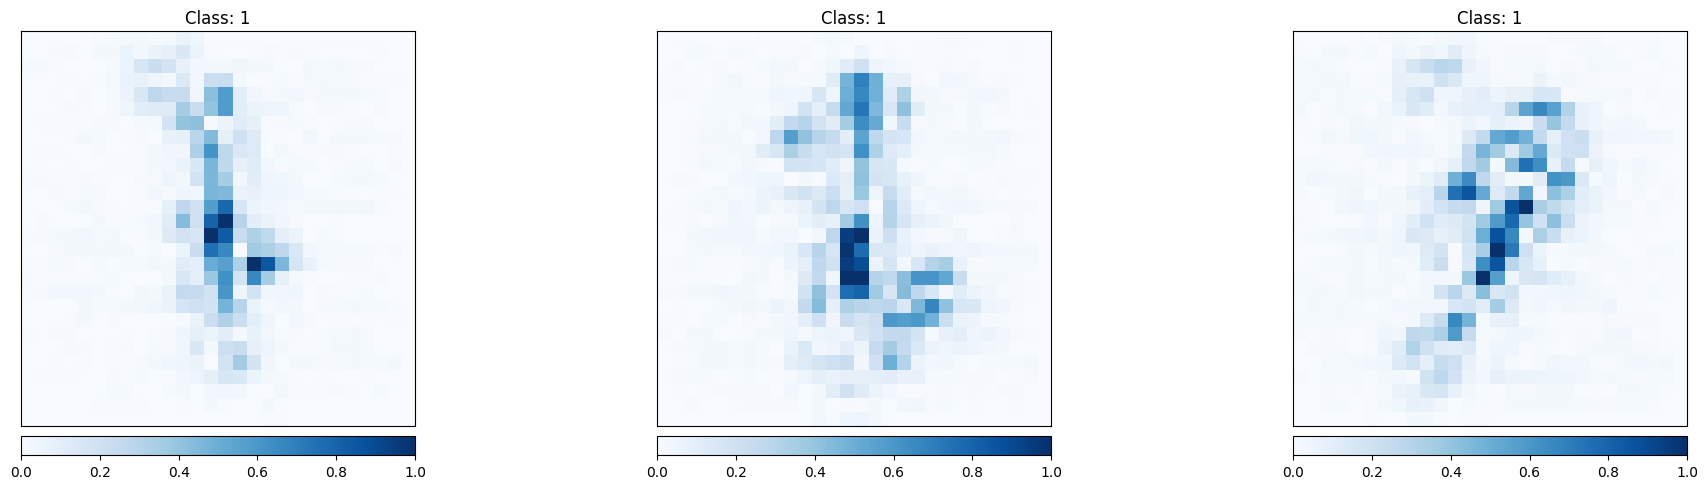

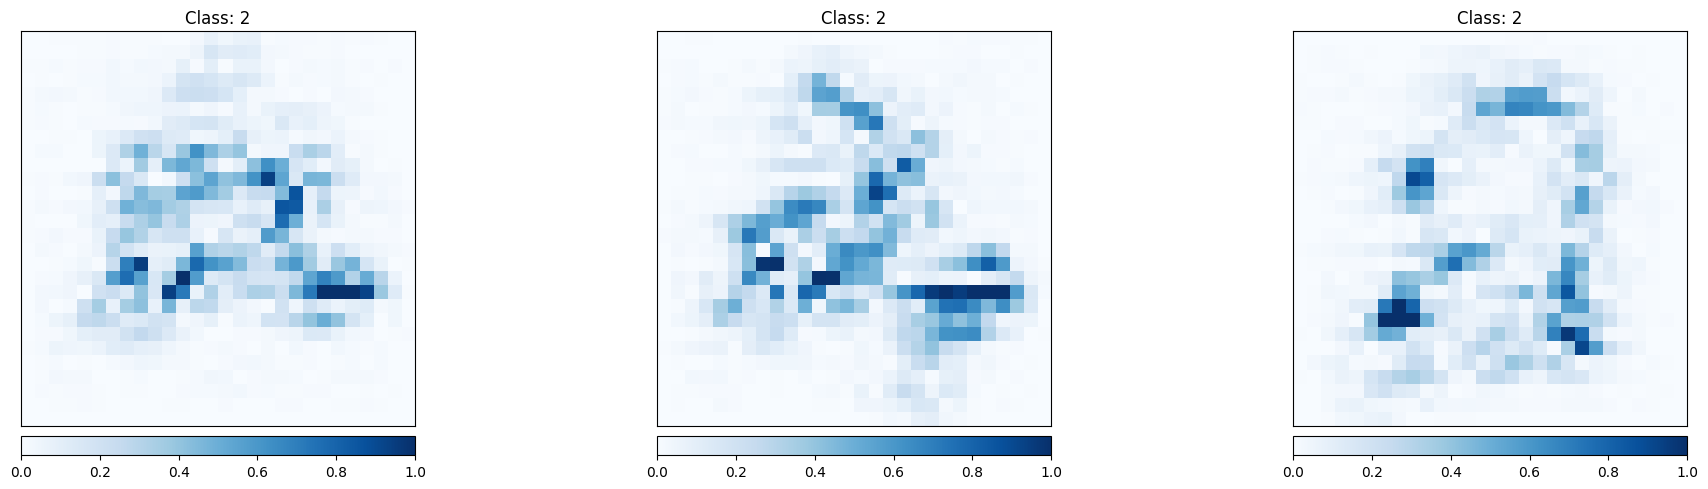

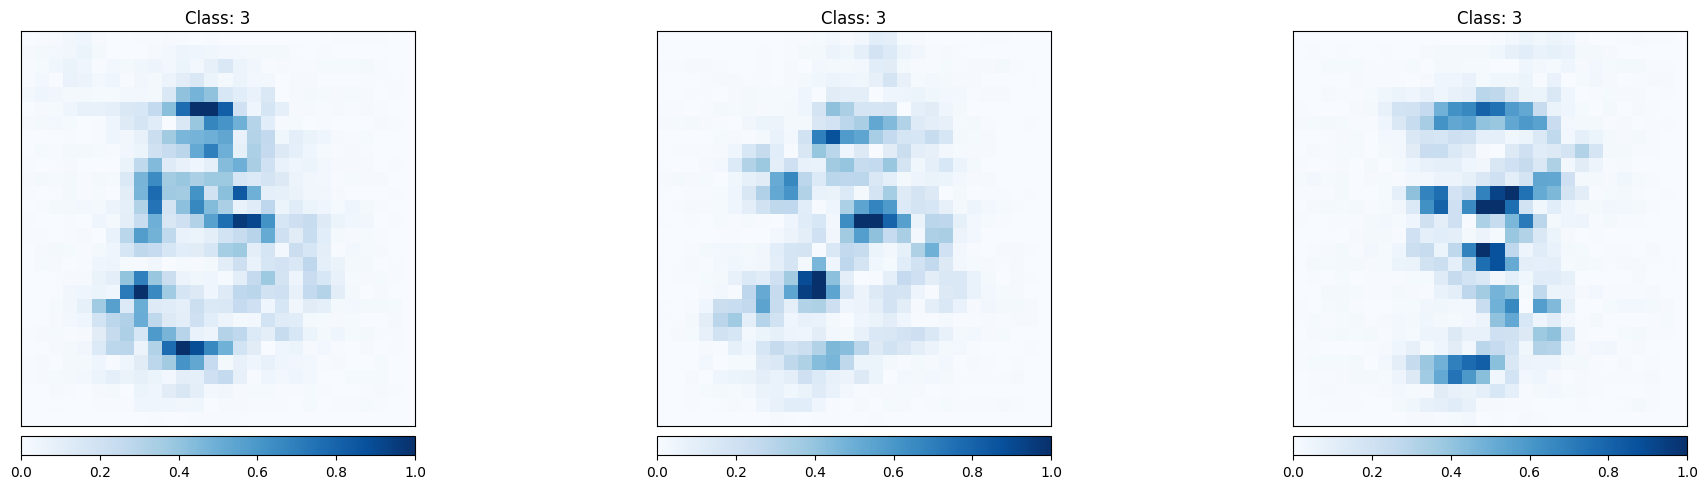

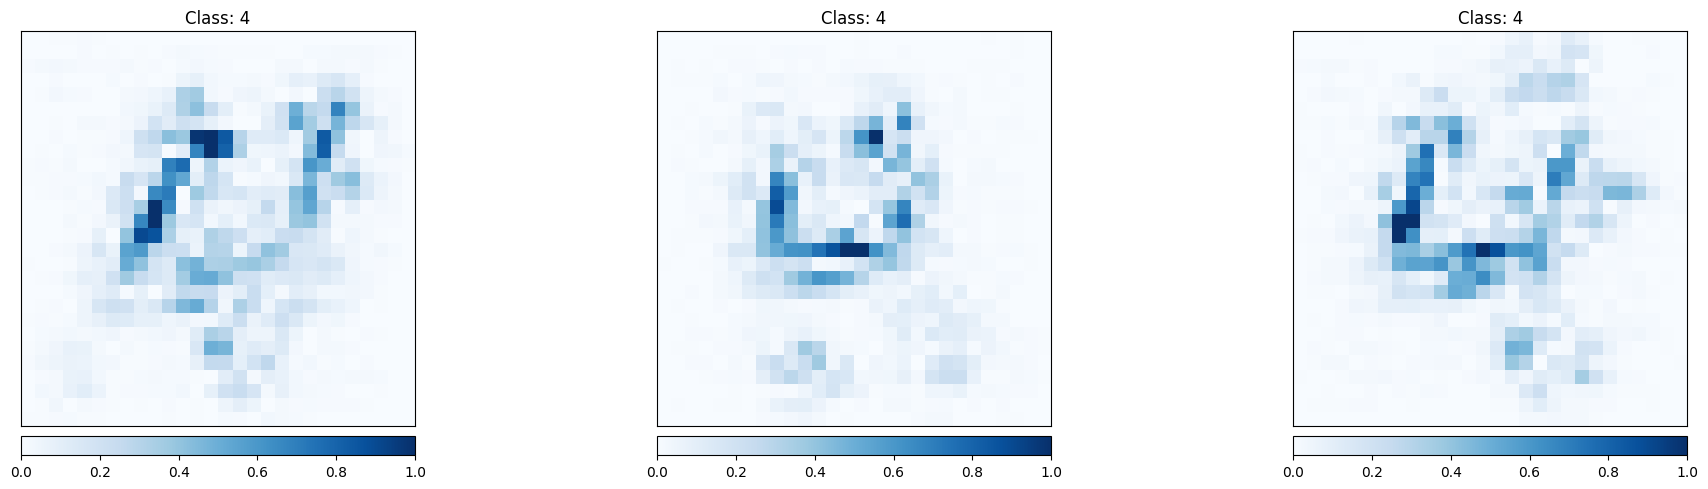

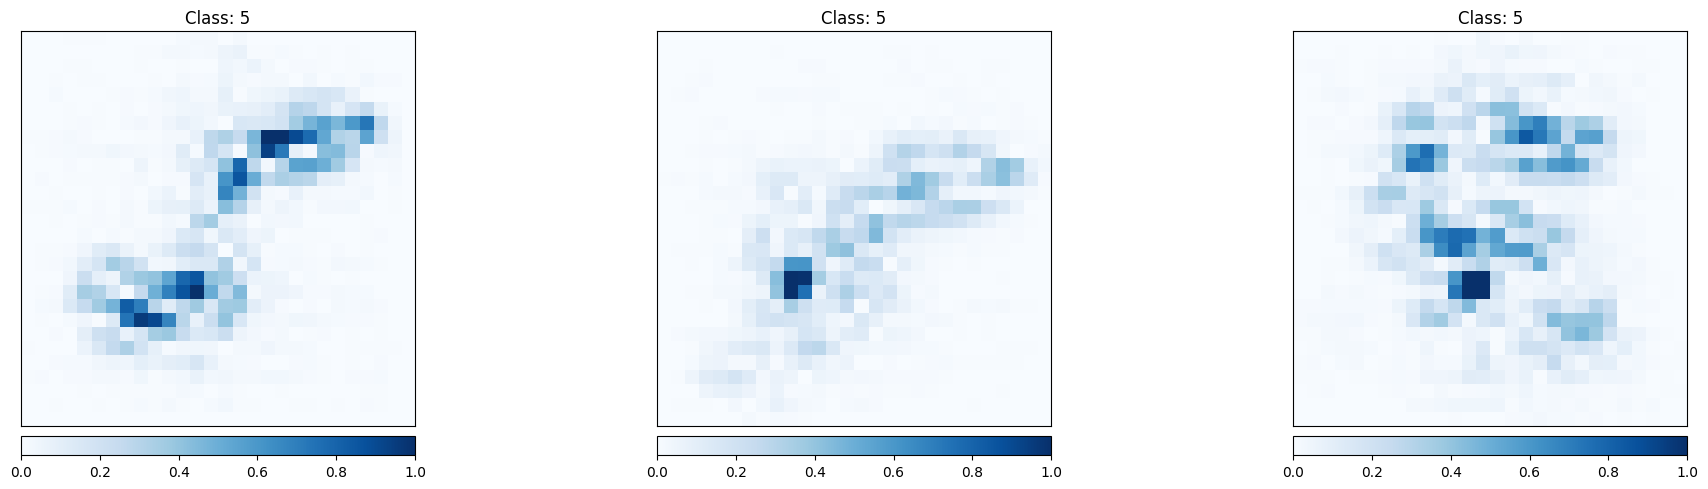

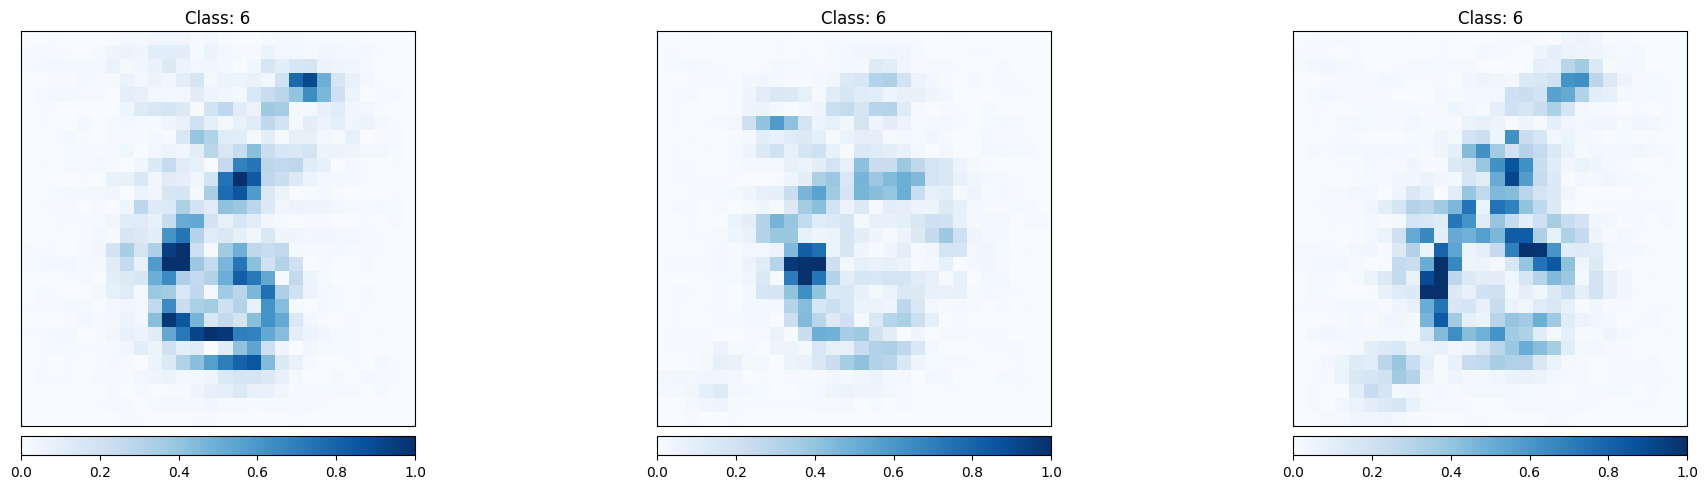

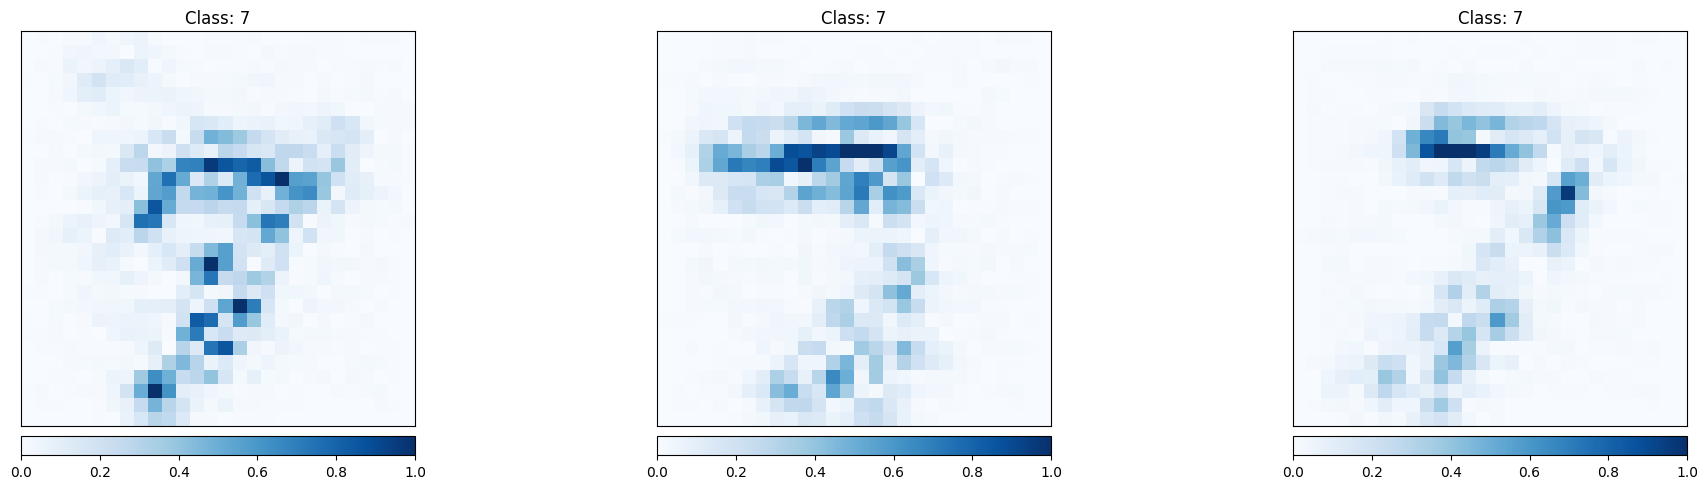

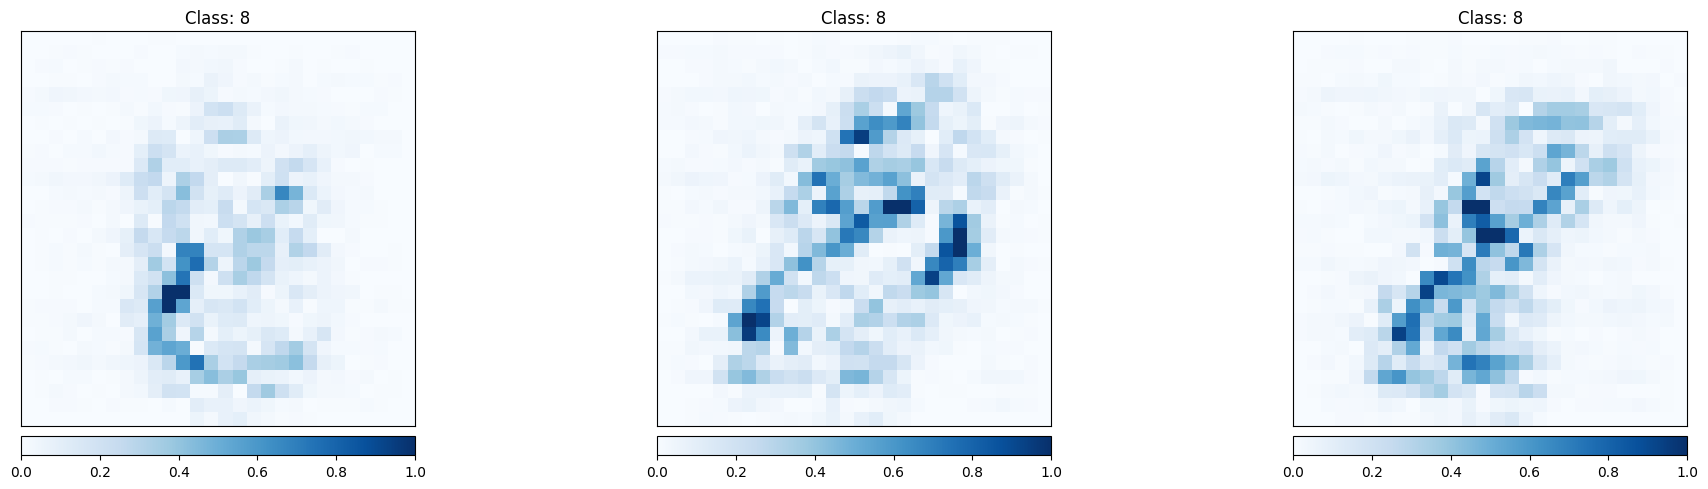

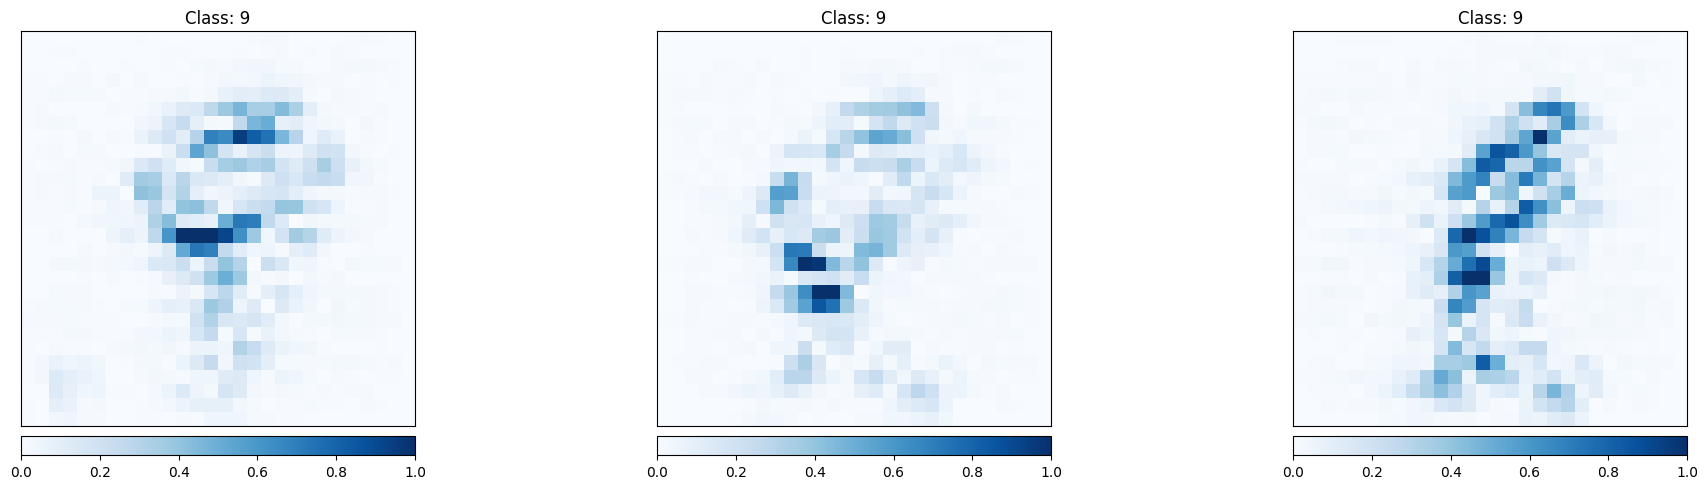

In [3]:
bs1 = [0.99]*10
bs2 = [0,0,0,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99]
bs3 = [0,0,0,0,0,0,0,0.99,0.99,0.99]
BS_LIST = [
  [0.99]*10,
  [0.50]*10,
  [0,0,0,0.99,0.99,0.99,0.99,0.99,0.99,0.99],
  [0,0,0,0.5,0.5,0.5,0.5,0.5,0.5,0.5],
  [0,0,0,0,0,0,0,0.99,0.99,0.99],
  [0,0,0,0,0,0,0,0.5,0.5,0.5]
]

for bs in BS_LIST:
  see_explainations(
    "ModernLeNet", 
    "DecoyMNIST", 
    bs,
    2,
    123
    )